# TCDL Graphs

This Jupyter notebook contains the code to generate image and text summaries for the annual TCDL Usage Report. Currently, this report requires three sets of input files.

1. **Dataverse-users-{date}.xlsx - Dataverse-users-{date}.csv**: This file may either come in a CSV or an Excel format but should be converted to CSV for reading into the script (the string to identify the most recent version may need to be updated in the script). It contains a list of all users in TDR, including those not affiliated with any particular institution (the monthly institutional reports only contain affiliated users) and metadata about them (e.g., date of account creation, date of last API usage). It must be generated by an installation-level superuser (i.e. TDL).
2. **dataverse-reports-{date}**: This is a folder containing the most recent monthly reports for all TDR institutions (as well as UT Arlington, a former member). No additional processing is needed for these files; the script will load all of the files in and concatenate them together.
3. Outputs from the main assessment script that can be run by any regular TDR user. **{date}_all-institutions_all-datasets-combined-with-dataverses.csv** contains additional dataset-level metadata for published datasets. **{date}_all-institutions_all-dataverses.csv** contains additional collection-level metadata for published collections. **{date}_all-institutions_all-files-deduplicated-PUBLISHED.csv** contains additional file-level metadata for published files (though it normally excludes older versions / deleted versions of files that are not in the most recent published version).

## Additional notes

The graphs are labeled according to their current slide number as of the 2026 TCDL presentation; these will likely be shifted in the future. For many graphs, there are various alternative visualizations of the same data that were tested out; these are usually immediately recognizable because they do not use the same color palette as the final presentation version. These are included in the event that they are useful or preferred in the future.

## Workflow set-up

This codeblock contains the module import statements and loading of the requisite input dataframes.

In [88]:
#| echo: false
#| warning: false
#| include: false

import ast
import json
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import os
import pandas as pd
from datetime import date, datetime
from matplotlib.patches import Circle
from matplotlib.gridspec import GridSpec
from utils import load_most_recent_file

# env file
with open('env.json', 'r') as file:
    env = json.load(file)

# Toggles
## Test environment (incomplete run, faster to complete)
test = env['TOGGLES']['test']
## Whether to exclue former/new members
current = env['TOGGLES']['current_members']
# ## Whether input is for all institutions or only one
# only_my_institution = env['TOGGLES']['only_my_institution']
# if only_my_institution:
#     institution_filename = env['INSTITUTION']['filename']
# else:
#     institution_filename = 'all-institutions'

# Dates, etc.
today = date.today()
today_pd = pd.Timestamp(today)
current_year = date.today().year
current_year_string = str(current_year)
first_of_current_year_string = current_year_string + '-01-01'
first_of_current_year = datetime.strptime(first_of_current_year_string, '%Y-%m-%d').date()
date_12_months_ago = today.replace(year=today.year - 1)
previous_tcdl = '2025-05-22'
previous_tcdl = pd.to_datetime(previous_tcdl)

# Graphical parameters
img_width = env['GRAPHS']['default_width']
img_height = env['GRAPHS']['default_height']
dpi = env['GRAPHS']['default_dpi']
format = env['GRAPHS']['default_extension']
title_font = env['GRAPHS']['default_title']
axis_font = env['GRAPHS']['default_axis_titles']
tick_font = env['GRAPHS']['default_axis_labels']
legend_font = env['GRAPHS']['default_legend']

# Lists and dictionaries
school_colors = env['SCHOOL_MAPS']['SCHOOL_COLORS']
school_names = env['SCHOOL_MAPS']['SCHOOL_NAMES']
display_names = env['SCHOOL_MAPS']['DISPLAY_NAMES']
current_members = env['SCHOOL_MAPS']['MEMBERS']['current_members']
current_members_and_none = env['SCHOOL_MAPS']['MEMBERS']['current_members_plus']
school_groups = env['SCHOOL_MAPS']['SCHOOL_GROUPS']['by_size']

# Get directories
script_dir = os.getcwd()
if test:
    outputs_dir = os.path.join(script_dir, 'test/outputs')
else:
    outputs_dir = os.path.join(script_dir, 'outputs')

# Load most recent df of deposits
pattern = '_all-institutions_all-datasets-combined-with-dataverses.csv'
datasets = load_most_recent_file(outputs_dir, pattern)

pattern = '_all-institutions_all-dataverses.csv'
dataverses = load_most_recent_file(outputs_dir, pattern)

pattern = '_all-institutions_all-files-deduplicated-PUBLISHED.csv'
files = load_most_recent_file(outputs_dir, pattern)
files['category_mime_type'] = files['original_mime_type'].str.extract(r'(\w+)/')

pattern = 'Dataverse-users-2026'
users = load_most_recent_file(script_dir, pattern)

The most recent file '20260608_all-institutions_all-datasets-combined-with-dataverses.csv' has been loaded successfully.
The most recent file '20260608_all-institutions_all-dataverses.csv' has been loaded successfully.


c:\Users\bmg3525\OneDrive - The University of Texas at Austin\Documents\scripts\tdr-assessment-scripts\utils.py:362: DtypeWarning: Columns (3,25,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


The most recent file '20260608_all-institutions_all-files-deduplicated-PUBLISHED.csv' has been loaded successfully.
The most recent file 'Dataverse-users-20260428.csv' has been loaded successfully.


## School color swatches

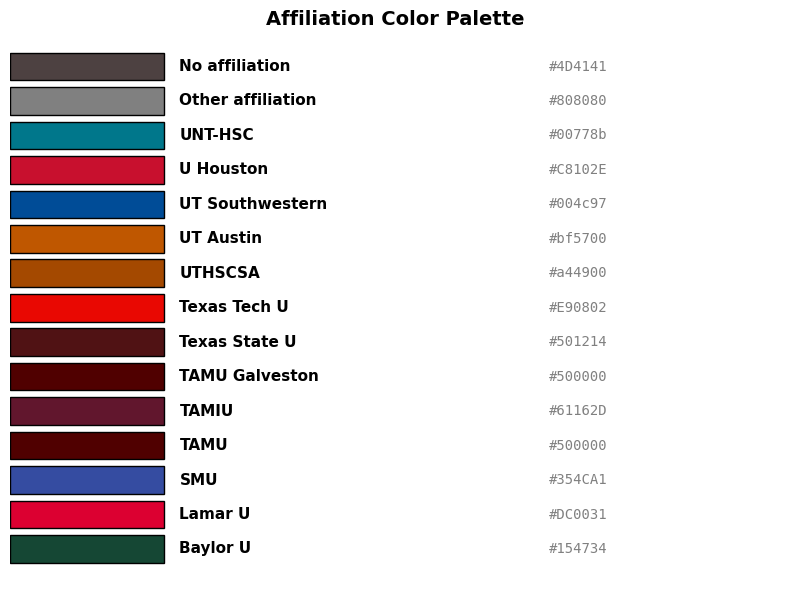

In [89]:
fig, ax = plt.subplots(figsize=(8, 6))

# Create color swatches
y_pos = np.arange(len(school_colors))

for i, (name, color) in enumerate(school_colors.items()):
    # Draw color rectangle
    rect = mpatches.Rectangle((0, i), 1, 0.8, facecolor=color, edgecolor='black', linewidth=1)
    ax.add_patch(rect)
    
    # Add institution name
    ax.text(1.1, i + 0.4, name, va='center', fontsize=11, fontweight='bold')
    
    # Add hex code
    ax.text(3.5, i + 0.4, color, va='center', fontsize=10, family='monospace', color='gray')

ax.set_xlim(0, 5)
ax.set_ylim(-0.5, len(school_colors))
ax.set_yticks([])
ax.set_xticks([])
ax.set_title('Affiliation Color Palette', fontsize=14, fontweight='bold', pad=15)
ax.axis('off')

plt.tight_layout()
plt.show()

## Preliminary data manipulation

These two codeblocks contain basic standardization and manipulation of the dataframes. They also define numerous lists or dictionaries that are called later in the script to standardize institutions' names and colors.

In [90]:
# Standardize order of size bin labels (for datasets)
bin_labels = [
    '0-10 kB',
    '10 kB-1 MB',
    '1-100 MB',
    '100 MB-1 GB',
    '1-10 GB',
    '10-15 GB',
    '15-20 GB',
    '20-25 GB',
    '25-30 GB',
    '30-40 GB',
    '40-50 GB',
    '>50 GB'
]

In [91]:
# All datasets

# Users
## Create full name column
users['Full Name'] = users['First Name'] + ' ' + users['Last Name']
## Remove TDL / test accounts
users_real = users[~users['Email'].str.contains('mailinator.com|tdl.student', na=False) & ~users['Full Name'].str.contains('Lauland|Smutniak|Ryan Steans|Mumma|Admin|Nicholas Woodward', na=False, case=False)]

# Filter to remove certain institutions (former/recent TDR members)
if current:
    # Filter to keep only current members and "No affiliation"
    files = files[files['institution'].isin(current_members_and_none)]
    datasets = datasets[datasets['institution_standardized'].isin(current_members_and_none)]
    dataverses = dataverses[dataverses['institution_standardized'].isin(current_members_and_none)]

# Files
## Drop any duplicate file types
files_dedup = files.drop_duplicates(subset=['doi', 'original_mime_type'])

# Standardizing institution affiliation
users_real['Affiliation_Standardized'] = users_real['Affiliation']
users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].replace(school_names)
users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].fillna('No affiliation')
## Replace affiliations not in the list with 'Other affiliation'
users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].apply(lambda x: x if x in current_members_and_none else 'Other affiliation')

## Remove sandbox datasets
datasets = datasets[~datasets['identifier'].str.startswith('FK2/')]
## Remove deaccessioned datasets
datasets_exist_df = datasets.dropna(subset=["createTime"])
## Remove draft datasets (but retain previously published datasets that are now in draft)
datasets_published_df = datasets_exist_df.dropna(subset=["publicationDate"])
## Get *only* unpublishe datasets
datasets_unpublished_df = datasets_exist_df[datasets_exist_df['publicationDate'].isna()]

# ########------------- TEMP
# datasets = datasets[~datasets['identifier_x'].str.startswith('FK2/')]
# datasets_exist_df = datasets.dropna(subset=["createTime_x"])
# datasets_published_df = datasets_exist_df.dropna(subset=["publicationDate_x"])
# ########------------- TEMP 


## Remove parent institution-level collections
### Remove rows where dataverse_name is blank AND dataverseType is ORGANIZATIONS_INSTITUTIONS AND released is Yes
dataverses_actual = dataverses[~(
    (dataverses['dataverse_name'].isna() | (dataverses['dataverse_name'].str.strip() == '')) &
    (dataverses['dataverseType'] == 'ORGANIZATIONS_INSTITUTIONS') &
    (dataverses['released'] == 'Yes')
)]
## Remove unpublished dataverses
dataverses_published = dataverses_actual[dataverses_actual["released"] == "Yes"]

print(f"Total number of datasets: {len(datasets)}\n")
print(f"Total number of existing (non-deaccessioned) datasets: {len(datasets_exist_df)}\n")
print(f"Total number of published datasets: {len(datasets_published_df)}\n")
print(f"Total number of unpublished datasets: {len(datasets_unpublished_df)}\n")
print(f"Total number of dataverses: {len(dataverses_actual)}\n")
print(f"Total number of published dataverses: {len(dataverses_published)}\n")

Total number of datasets: 3873

Total number of existing (non-deaccessioned) datasets: 3836

Total number of published datasets: 2974

Total number of unpublished datasets: 862

Total number of dataverses: 1331

Total number of published dataverses: 977



C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1350048764.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_real['Affiliation_Standardized'] = users_real['Affiliation']
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1350048764.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_real['Affiliation_Standardized'] = users_real['Affiliation_Standardized'].replace(school_names)
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1350048764.py:23: SettingWithCopyWarning: 
A value is tryin

## Slide 5: TDR Users Over Time

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1009987964.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataverses_actual['creationDate'] = pd.to_datetime(dataverses_actual['creationDate'], errors='coerce')
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1009987964.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_appearance['year_month_created'] = first_appearance['creationDate'].dt.to_period('M')
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1009987964.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  first_appearance['year_month_created'] = first_appearance['created_final'].dt.to_period('M')
C:\Users\bmg3525\AppData\L

    year_month_created  new_collections  total_collections
0              2017-01                2                  2
1              2017-02                2                  4
2              2017-03                3                  7
3              2017-04                3                 10
4              2017-05                1                 11
..                 ...              ...                ...
107            2026-01                9                624
108            2026-02               11                635
109            2026-03                8                643
110            2026-04                8                651
111            2026-05                1                652

[112 rows x 3 columns]


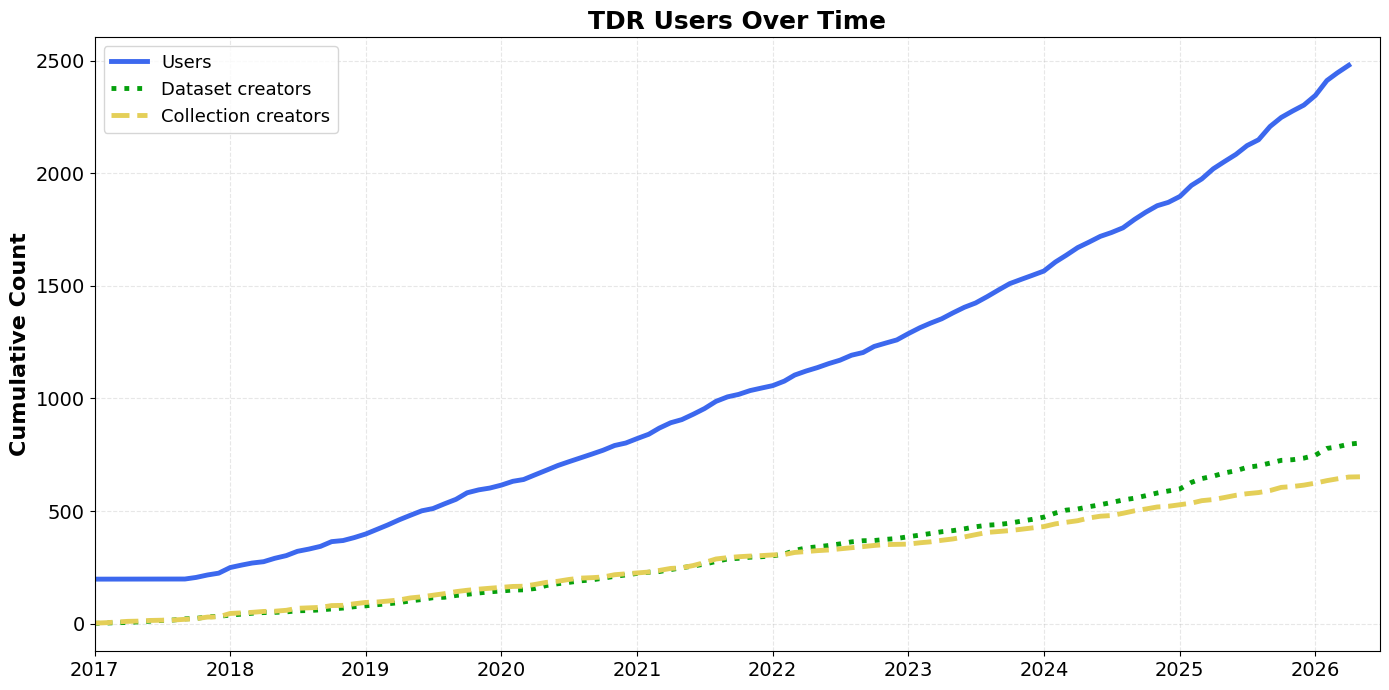

In [92]:
# To get summaries of dataset creators and collection creators
## Collections
### For each unique contactIdentifier, get the earliest date
#### Convert to datetime, coercing errors to NaT
dataverses_actual['creationDate'] = pd.to_datetime(dataverses_actual['creationDate'], errors='coerce')
first_appearance = dataverses_actual.groupby('contactIdentifier')['creationDate'].min().reset_index()
first_appearance['year_month_created'] = first_appearance['creationDate'].dt.to_period('M')

### Count unique contacts per month (cumulative)
monthly_counts_dataverses = first_appearance.groupby('year_month_created').size().reset_index(name='new_collections')
monthly_counts_dataverses['total_collections'] = monthly_counts_dataverses['new_collections'].cumsum()

print(monthly_counts_dataverses)

## Datasets
### For each unique contactIdentifier, get the earliest date
datasets['created_final'] = pd.to_datetime(datasets['created_final'], errors='coerce')
first_appearance = datasets.groupby('dataset_depositor')['created_final'].min().reset_index()
first_appearance['year_month_created'] = first_appearance['created_final'].dt.to_period('M')
### Count unique contacts per month (cumulative)
monthly_counts_datasets = first_appearance.groupby('year_month_created').size().reset_index(name='new_datasets')
monthly_counts_datasets['total_datasets'] = monthly_counts_datasets['new_datasets'].cumsum()

### unique deposits - PUBLISHED
monthly_counts = datasets.groupby('year_month_published').size()
cumulative_counts = monthly_counts.cumsum()

# Convert index to datetime
cumulative_counts.index = pd.to_datetime(cumulative_counts.index)

dataset_publish_counts = cumulative_counts.reset_index()
dataset_publish_counts.columns = ['year_month', 'total']
dataset_publish_counts['category'] = 'Published'

### unique deposits - CREATED
monthly_counts = datasets.groupby('year_month_created').size()
cumulative_counts = monthly_counts.cumsum()

# Convert index to datetime
cumulative_counts.index = pd.to_datetime(cumulative_counts.index)

dataset_create_counts = cumulative_counts.reset_index()
dataset_create_counts.columns = ['year_month', 'total']
dataset_create_counts['category'] = 'Created'

### Concatenate
dataset_concat = pd.concat([dataset_publish_counts, dataset_create_counts], ignore_index=True)



users_plot = users_real.copy()
## Date conversions
users_plot['Last Login'] = pd.to_datetime(users_plot['Last Login']).dt.date
users_plot['Created'] = pd.to_datetime(users_plot['Created'])
### Extract year-month
users_plot['year_month_created'] = users_plot['Created'].dt.to_period('M')
### Count records per month
monthly_counts = users_plot.groupby('year_month_created').size()
### Convert to cumulative sum
cumulative_counts = monthly_counts.cumsum()
### Convert index to timestamp for plotting
cumulative_counts.index = cumulative_counts.index.to_timestamp()
### Format df
users_summary = cumulative_counts.reset_index()
users_summary.columns = ['year_month_created', 'total']
users_summary['category'] = 'Users'

# Combine all user dfs
## Datasets
datasets_summary = monthly_counts_datasets.copy()
datasets_summary = datasets_summary[['year_month_created', 'total_datasets']]
datasets_summary = datasets_summary[['year_month_created', 'total_datasets']].reset_index(drop=True)
datasets_summary.columns = ['year_month_created', 'total']
datasets_summary['category'] = 'Dataset creators'
datasets_summary['year_month_created'] = datasets_summary['year_month_created'].dt.to_timestamp()

## Collections
dataverses_summary = monthly_counts_dataverses.copy()
dataverses_summary = dataverses_summary[['year_month_created', 'total_collections']]
dataverses_summary.columns = ['year_month_created', 'total']
dataverses_summary['category'] = 'Collection creators'
dataverses_summary['year_month_created'] = dataverses_summary['year_month_created'].dt.to_timestamp()

combined_summary = pd.concat([users_summary, datasets_summary, dataverses_summary], ignore_index=True)

### Ensure year_month is datetime for plotting
combined_summary['year_month_created'] = pd.to_datetime(combined_summary['year_month_created'])

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Define colors and line styles for each category
styles = {
    'Users': {'color': "#3c68ee", 'linestyle': 'solid', 'linewidth': 3.5},
    'Dataset creators': {'color': "#05A00D", 'linestyle': 'dotted', 'linewidth': 3.5},
    'Collection creators': {'color': "#E4CF58", 'linestyle': 'dashed', 'linewidth': 3.5}
}

# Plot each category
for category in combined_summary['category'].unique():
    data = combined_summary[combined_summary['category'] == category]
    style = styles[category]
    
    ax.plot(data['year_month_created'], data['total'], 
            label=category,
            color=style['color'], 
            linestyle=style['linestyle'],
            linewidth=style['linewidth'])

# Labels, etc.
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), today_pd)
ax.set_ylabel('Cumulative Count', fontsize=axis_font, fontweight='bold')
ax.set_title('TDR Users Over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')

# Add legend
ax.legend(fontsize=legend_font, loc='upper left')

plt.tight_layout()
plt.show()

## Alternative to Slide 5

This is a bar plot representation that is partitioned by institution.

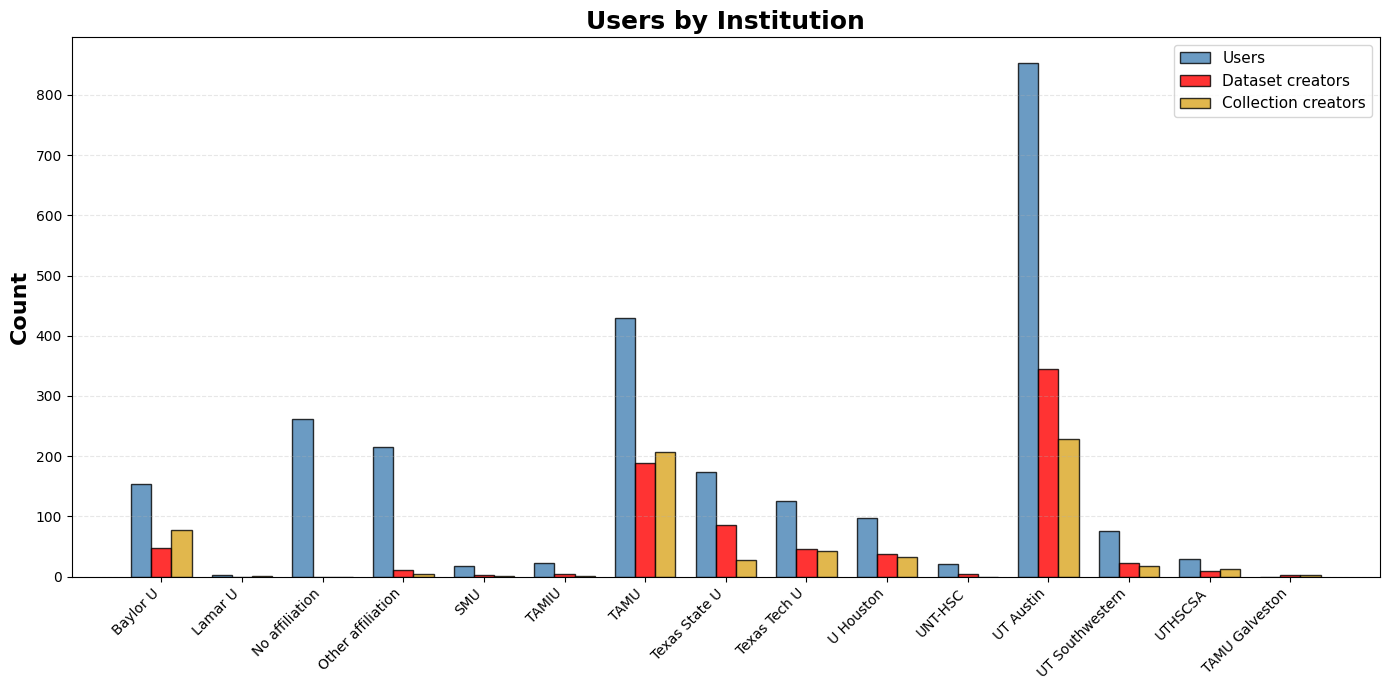

In [93]:
# Group by institution and count unique users
users_by_institution = users_real.groupby('Affiliation_Standardized').size().reset_index(name='total')
users_by_institution.rename(columns={'Affiliation_Standardized': 'institution'}, inplace=True)
users_by_institution['category'] = 'Users'

# Group by institution and count unique contactIdentifiers (contacts/depositors)
datasets_by_institution = datasets.groupby('institution_standardized')['dataset_depositor'].nunique().reset_index(name='total')
datasets_by_institution.rename(columns={'institution_standardized': 'institution'}, inplace=True)
datasets_by_institution['category'] = 'Dataset creators'

# Group by institution and count unique dataverses
dataverses_by_institution = dataverses_actual.groupby('institution_standardized')['contactIdentifier'].nunique().reset_index(name='total')
dataverses_by_institution.rename(columns={'institution_standardized': 'institution'}, inplace=True)
dataverses_by_institution['category'] = 'Collection creators'

# Combine all three
combined_by_institution = pd.concat([users_by_institution, datasets_by_institution, dataverses_by_institution], ignore_index=True)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Get unique institutions and categories
institutions = combined_by_institution['institution'].unique()
categories = ['Users', 'Dataset creators', 'Collection creators']

# Set up bar positions
x = np.arange(len(institutions))
width = 0.25  # Width of each bar

# Define colors for each category
colors = {
    'Users': 'steelblue',
    'Dataset creators': 'red',
    'Collection creators': 'goldenrod'
}

# Plot bars for each category
for i, category in enumerate(categories):
    data = combined_by_institution[combined_by_institution['category'] == category]
    
    # Create a mapping of institution to total for this category
    values = [data[data['institution'] == inst]['total'].values[0] if inst in data['institution'].values else 0 
              for inst in institutions]
    
    ax.bar(x + (i - 1) * width, values, width, 
           label=category, color=colors[category], edgecolor='black', alpha=0.8)

# Customize the plot
ax.set_xlabel('', fontsize=16, fontweight='bold')
ax.set_ylabel('Count', fontsize=16, fontweight='bold')
ax.set_title('Users by Institution', fontsize=18, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(institutions, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Alternative to Slide 5

This is a bar plot partitioned by institution and then faceted into three subplots by semi-arbitrary cutoffs for school size.

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\2628231929.py:60: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8)


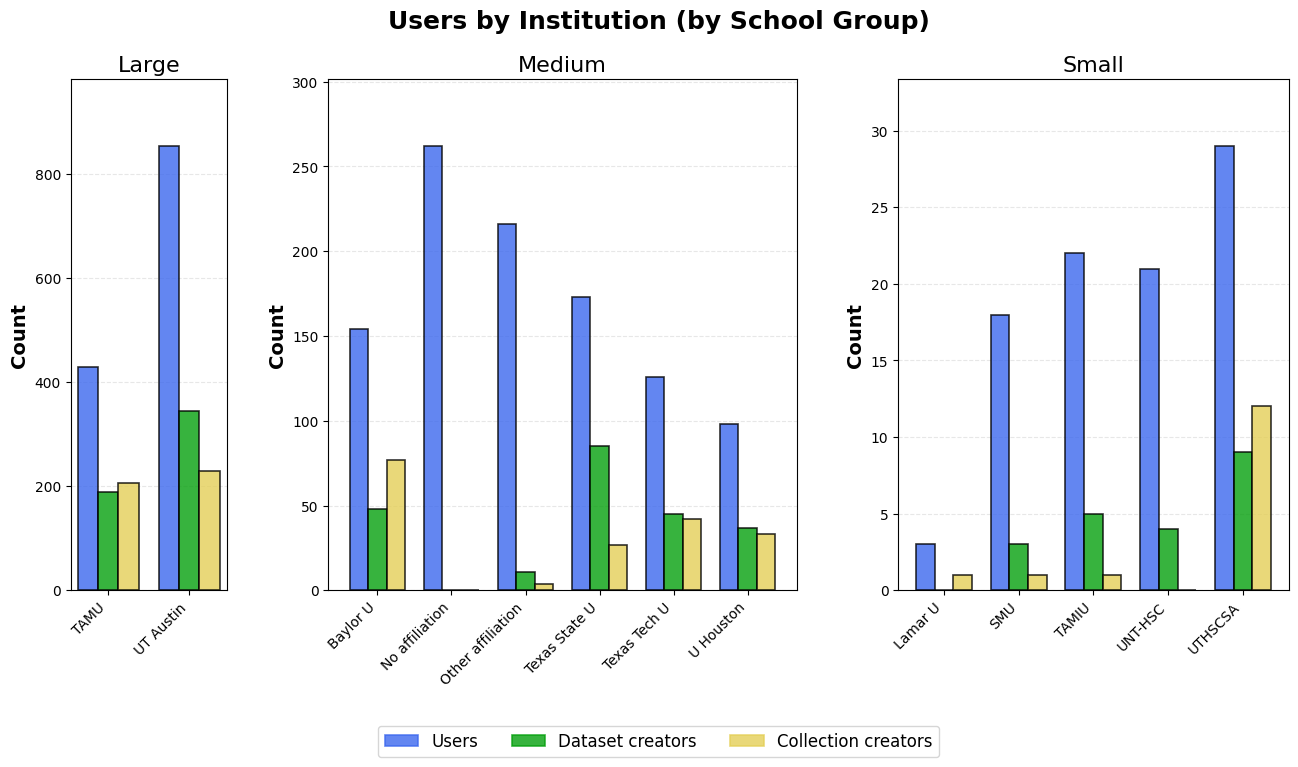

In [94]:
# Calculate width ratios based on number of schools in each group
width_ratios = [len(schools) for schools in school_groups.values()]

# Create figure with GridSpec
fig = plt.figure(figsize=(14, 7))
gs = GridSpec(1, 3, width_ratios=width_ratios, wspace=0.3)

bar_width = 0.25
categories = ['Users', 'Dataset creators', 'Collection creators']
colors = {
    'Users': '#3c68ee',
    'Dataset creators': '#05A00D',
    'Collection creators': '#E4CF58'
}

for idx, (group_name, schools) in enumerate(school_groups.items()):
    ax = fig.add_subplot(gs[0, idx])
    
    # Filter data for this group
    group_data = combined_by_institution[combined_by_institution['institution'].isin(schools)]
    institutions_in_group = group_data['institution'].unique()
    
    x_pos = np.arange(len(institutions_in_group))
    # Increase y-axis max
    y_max = group_data['total'].max()
    ax.set_ylim(0, y_max * 1.15)

    # Plot grouped bars for each category
    for i, category in enumerate(categories):
        category_data = group_data[group_data['category'] == category]
        
        # Create a mapping of institution to total for this category
        values = [category_data[category_data['institution'] == inst]['total'].values[0] 
                  if inst in category_data['institution'].values else 0 
                  for inst in institutions_in_group]
        
        ax.bar(x_pos + (i - 1) * bar_width, values, bar_width, 
               label=category, color=colors[category], edgecolor='black', linewidth=1.2, alpha=0.8)
        
        # # Add value labels on top of bars
        # for j, val in enumerate(values):
        #     if val > 0:
        #         ax.text(j + (i - 1) * bar_width, val + (y_max * 0.01), f'{int(val)}', 
        #                 ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(institutions_in_group, rotation=45, ha='right')
    ax.set_ylabel('Count', fontsize=14, fontweight='bold')
    ax.set_xlabel('', fontsize=11, fontweight='bold')
    ax.set_title(group_name, fontsize=16)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, loc='upper right')  # Keep individual legends for now

# Remove individual legends and create a single shared legend
for ax in fig.get_axes():
    ax.get_legend().remove()

# Create shared legend below the plots
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8) 
           for cat in categories]
fig.legend(handles, categories, loc='lower center', bbox_to_anchor=(0.5, -0.1), 
           ncol=3, fontsize=12, frameon=True)

fig.suptitle('Users by Institution (by School Group)', fontsize=18, fontweight='bold', y=0.98)
plt.subplots_adjust(left=0.08, right=0.95, top=0.88, bottom=0.15)
plt.show()

## Alternative to Slide 5

This is a bar plot that is nearly identical to the preceding alternative representation, just with the bars horizontal instead of vertical.

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\175459354.py:61: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8)
C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\175459354.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.99])


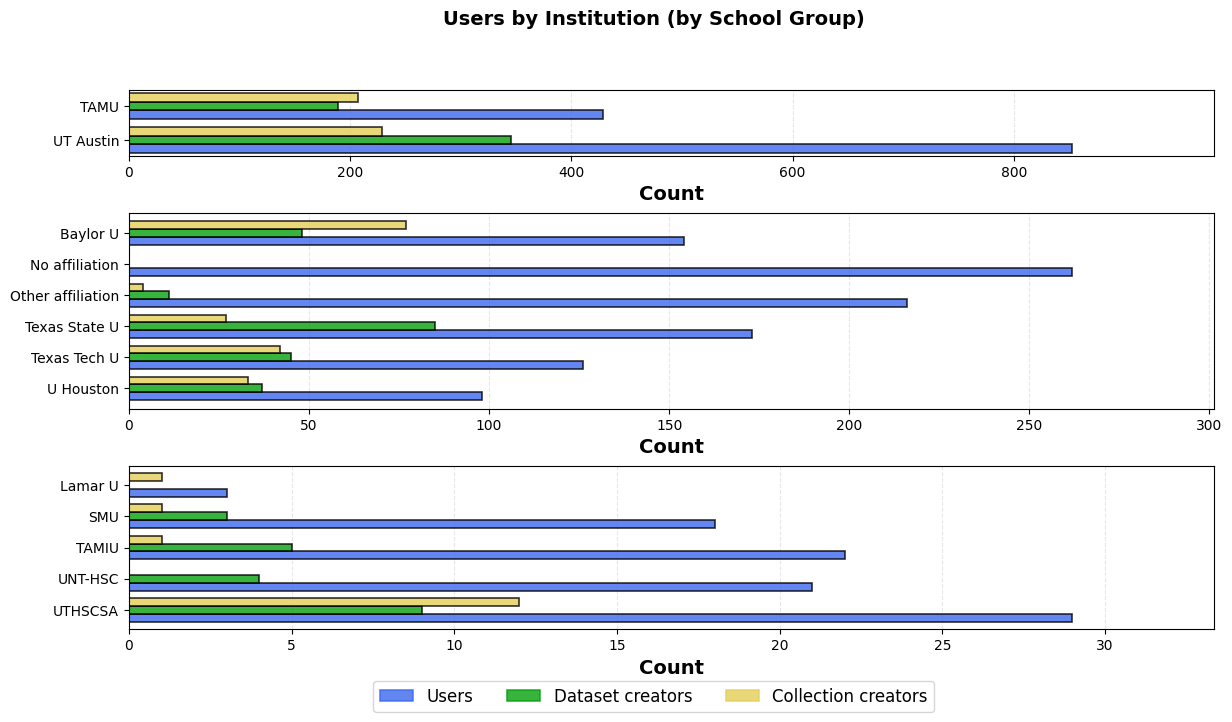

In [95]:
# Calculate height ratios based on number of schools in each group
height_ratios = [len(schools) for schools in school_groups.values()]

# Create figure with GridSpec
fig = plt.figure(figsize=(14, 7))
gs = GridSpec(3, 1, height_ratios=height_ratios, hspace=0.4)

bar_width = 0.25
categories = ['Users', 'Dataset creators', 'Collection creators']
colors = {
    'Users': '#3c68ee',
    'Dataset creators': '#05A00D',
    'Collection creators': '#E4CF58'
}

for idx, (group_name, schools) in enumerate(school_groups.items()):
    ax = fig.add_subplot(gs[idx, 0])
    
    # Filter data for this group
    group_data = combined_by_institution[combined_by_institution['institution'].isin(schools)]
    institutions_in_group = sorted(group_data['institution'].unique(), reverse=True)
    
    y_pos = np.arange(len(institutions_in_group))
    
    # Plot grouped bars for each category
    for i, category in enumerate(categories):
        category_data = group_data[group_data['category'] == category]
        
        # Create a mapping of institution to total for this category
        values = [category_data[category_data['institution'] == inst]['total'].values[0] 
                  if inst in category_data['institution'].values else 0 
                  for inst in institutions_in_group]
        
        ax.barh(y_pos + (i - 1) * bar_width, values, bar_width, 
                label=category, color=colors[category], edgecolor='black', linewidth=1.2, alpha=0.8)
        
        # # Add value labels on bars
        # for j, val in enumerate(values):
        #     if val > 0:
        #         ax.text(val + (max(values) * 0.02), j + (i - 0.5) * bar_width, f'{int(val)}', 
        #                 ha='left', va='center', fontsize=10)
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(institutions_in_group)
    ax.set_xlabel('Count', fontsize=14, fontweight='bold')
    ax.set_ylabel('', fontsize=11, fontweight='bold')
    # ax.set_title(group_name, fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Increase x-axis max
    x_max = group_data['total'].max()
    ax.set_xlim(0, x_max * 1.15)

# Remove individual legends and create a single shared legend
for ax in fig.get_axes():
    if ax.get_legend():
        ax.get_legend().remove()

# Create shared legend below the plots
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8) 
           for cat in categories]
fig.legend(handles, categories, loc='lower center', bbox_to_anchor=(0.5, -0.02), 
           ncol=3, fontsize=12, frameon=True)

fig.suptitle('Users by Institution (by School Group)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.99])
plt.show()

## Slide 6: TDR Users by Last Login

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\215757709.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  users_plot['Last Login'] = pd.to_datetime(users_plot['Last Login'])


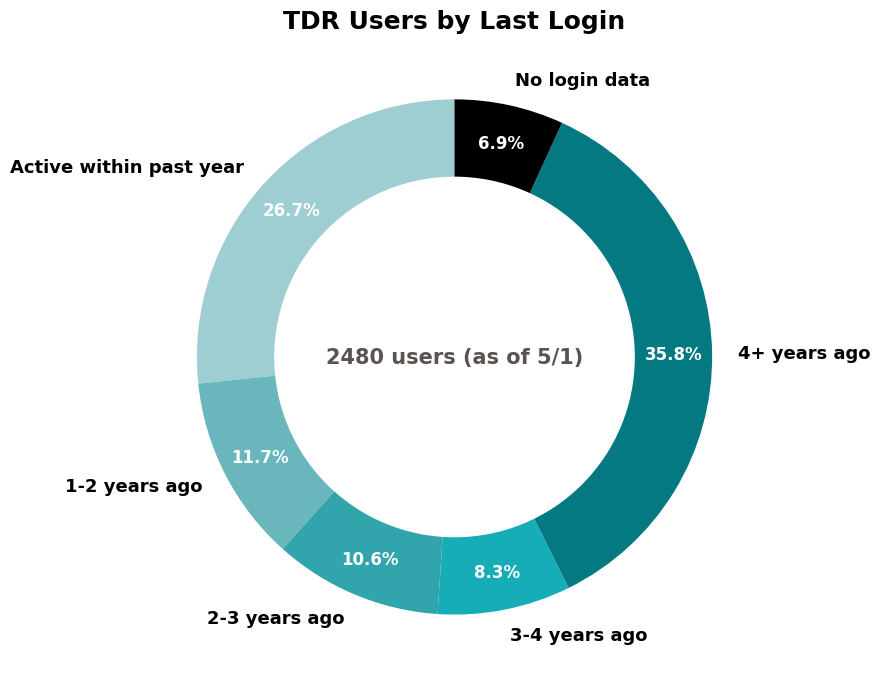

In [96]:
#| echo: false
#| warning: false

users_plot = users_real.copy()

# Convert 'Last Login' to datetime
## This is slightly different than the previous date conversion for this variable
users_plot['Last Login'] = pd.to_datetime(users_plot['Last Login'])
## Calculate days since last login
users_plot['Days Since Login'] = (today_pd - users_plot['Last Login']).dt.days

# Create bins for last login
def bin_last_login(days):
    if pd.isna(days):
        return 'No login data'
    elif days <= 365:
        return 'Active within past year'
    elif days <= 730:
        return '1-2 years ago'
    elif days <= 1095:
        return '2-3 years ago'
    elif days <= 1460:
        return '3-4 years ago'
    else:
        return '4+ years ago'
users_plot['Login Bin'] = users_plot['Days Since Login'].apply(bin_last_login)

## Count by bin
login_counts = users_plot['Login Bin'].value_counts()
## Define order for plotting
category_order = [
    'Active within past year',
    '1-2 years ago',
    '2-3 years ago',
    '3-4 years ago',
    '4+ years ago',
    'No login data'
]
## Reorder the series
login_counts = login_counts.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################
fig, ax = plt.subplots(figsize=(10, img_height))

# Define colors for each bin
colors = ["#9eced1", "#69b6bc", "#32a4ac", "#16adb8", "#047981", "#000000"]

# Create donut chart
wedges, texts, autotexts = ax.pie(
    login_counts.values,
    labels=login_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 13},
    pctdistance=0.85
)
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
    autotext.set_color('white')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)
# Create text to go in the donut hole
total_count = len(users_plot)
ax.text(0, 0, f'{total_count} users (as of 5/1)', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Labels, etc.
ax.set_title('TDR Users by Last Login', fontsize=title_font, fontweight='bold', pad=5)

plt.tight_layout()
plt.show()

## Slilde 7: TDR Users by Number of Deposits

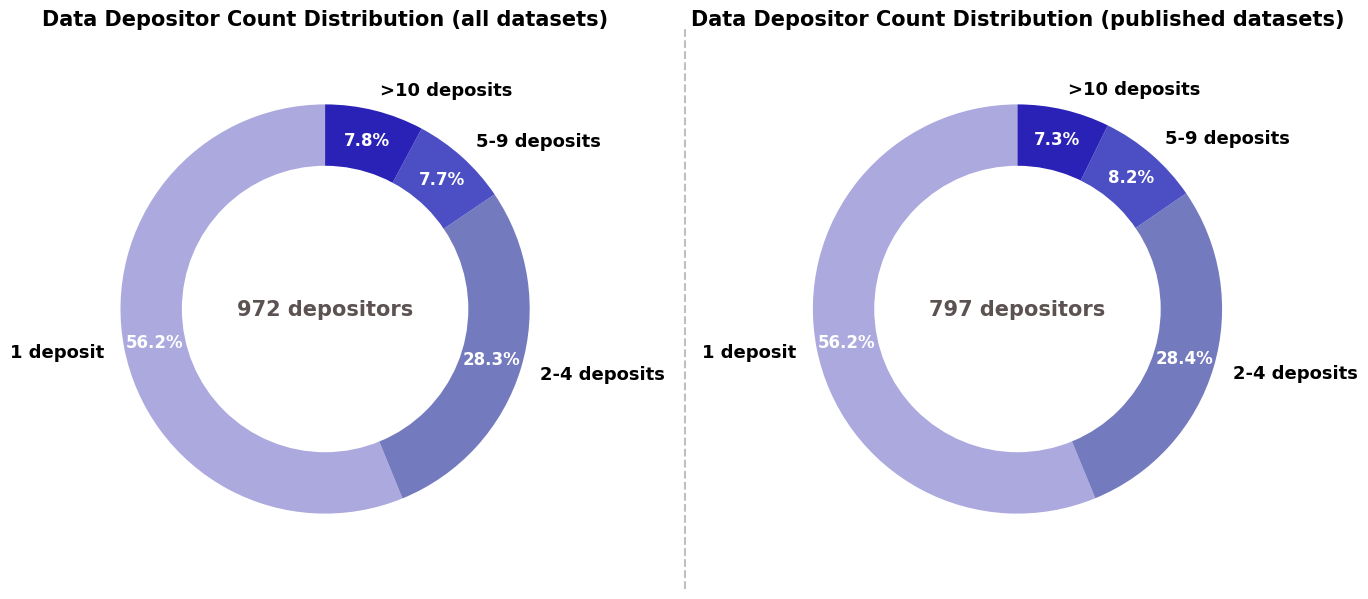

In [97]:
# Summarize counts for published deposits
datasets_plot = datasets_published_df.copy()
depositor_count_pub = datasets_plot['dataset_depositor'].value_counts().reset_index()

def bin_deposits(count):
    if count ==1:
        return '1 deposit'
    elif count >1 and count <5:
        return '2-4 deposits'
    elif count >4 and count < 10:
        return '5-9 deposits'
    else:
        return '>10 deposits'

depositor_count_pub['Deposit Bin'] = depositor_count_pub['count'].apply(bin_deposits)
depositor_bin_count = depositor_count_pub['Deposit Bin'].value_counts()

category_order = [
    '1 deposit',
    '2-4 deposits',
    '5-9 deposits',
    '>10 deposits'
]
depositor_bin_count = depositor_bin_count.reindex(category_order)

# Summarize counts for all deposits
datasets_plot = datasets.copy()
depositor_count_all = datasets_plot['depositor'].value_counts().reset_index()
depositor_count_all['Deposit Bin'] = depositor_count_all['count'].apply(bin_deposits)
depositor_count_all_count = depositor_count_all['Deposit Bin'].value_counts()
depositor_count_all_count = depositor_count_all_count.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(img_width, img_height))

# All depositors
colors = ["#aca9df", "#747abe", "#4c4ec4", "#2a22b6"]

wedges, texts, autotexts = ax1.pie(
    depositor_bin_count.values,
    labels=depositor_bin_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 13},
    pctdistance=0.85
)
for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
    autotext.set_color('white')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax1.add_artist(centre_circle)
# Add text in the donut hole
total_count = len(depositor_count_pub)
ax1.text(0, 0, f'{total_count} depositors', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Labels, etc.
ax1.set_title('Data Depositor Count Distribution (published datasets)', fontsize=15, fontweight='bold', pad=20)



# Published datasets
wedges, texts, autotexts = ax2.pie(
    depositor_count_all_count.values,
    labels=depositor_count_all_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 13},
    pctdistance=0.85
)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(13)
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)
    autotext.set_color('white')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax2.add_artist(centre_circle)
# Add text in the donut hole
total_count = len(depositor_count_all)
ax2.text(0, 0, f'{total_count} depositors', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Labels, etc.
ax2.set_title('Data Depositor Count Distribution (all datasets)', fontsize=15, fontweight='bold', pad=20)

# Add divider line and space
plt.subplots_adjust(wspace=1)
fig.add_artist(plt.Line2D([0.5, 0.5], [0.1, 0.9], 
                          transform=fig.transFigure, 
                          color='gray', 
                          linewidth=1.5, 
                          linestyle='--',
                          alpha=0.5))

plt.tight_layout()
plt.show()

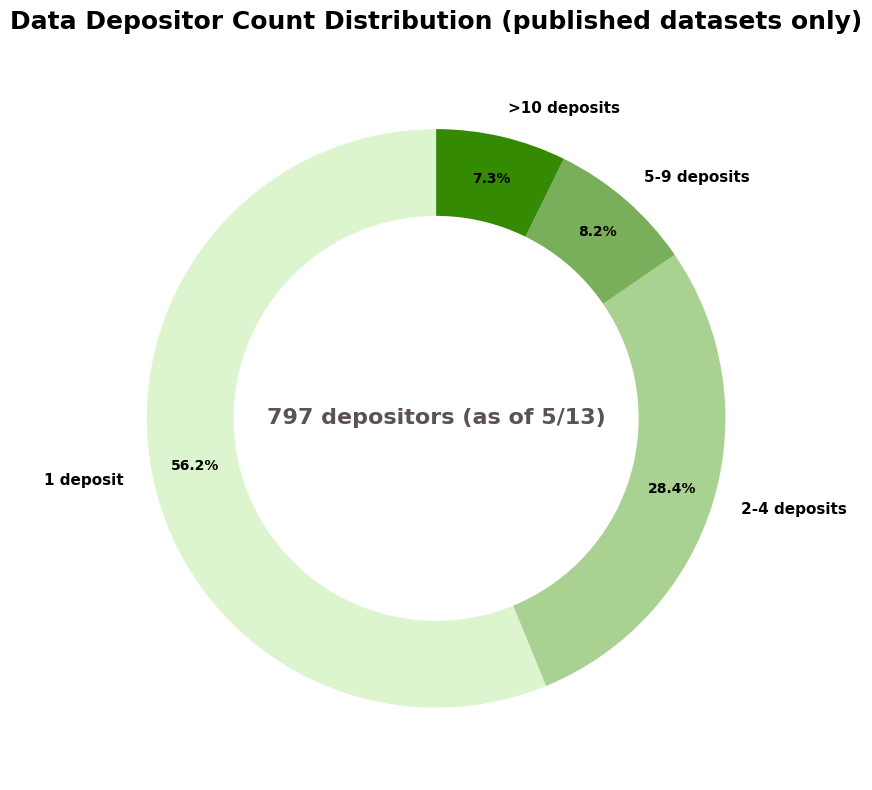

In [98]:
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each bin
colors = ["#dcf5ce", "#a9d192", "#79ae5a", "#358a04"]

# Create donut chart
wedges, texts, autotexts = ax.pie(
    depositor_bin_count.values,
    labels=depositor_bin_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11},
    pctdistance=0.85
)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(11)

# Control percentage weight independently
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
    autotext.set_color('black')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

total_count = len(depositor_count_pub)
ax.text(0, 0, f'{total_count} depositors (as of 5/13)', ha='center', va='center', 
        fontsize=16, fontweight='bold', color="#5C5252")

# Customize the plot
ax.set_title('Data Depositor Count Distribution (published datasets only)', fontsize=title_font, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

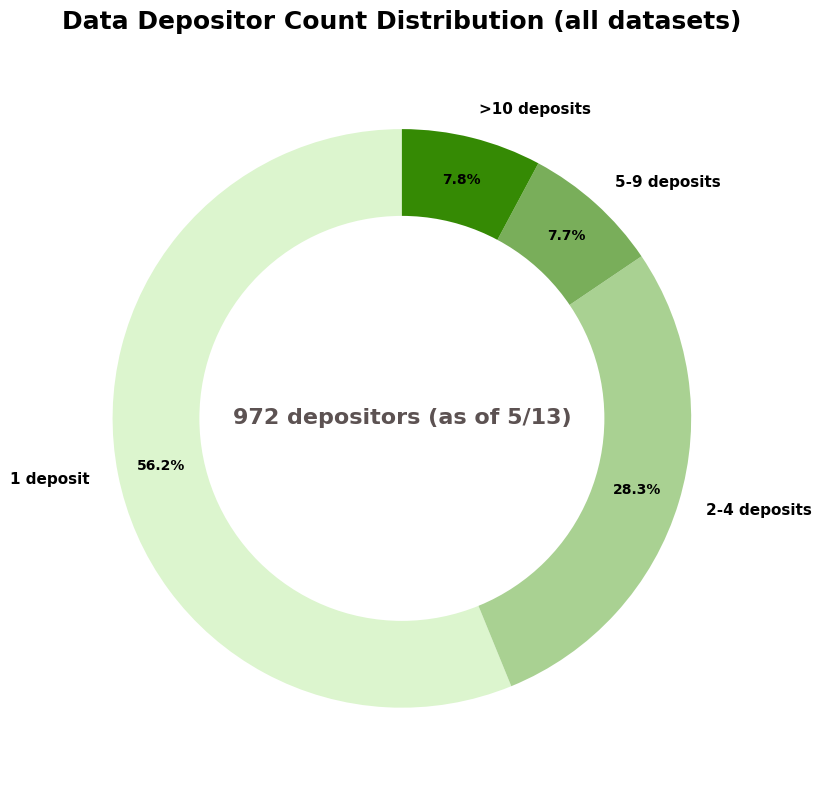

In [99]:
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each bin
colors = ["#dcf5ce", "#a9d192", "#79ae5a", "#358a04"]

# Create donut chart
wedges, texts, autotexts = ax.pie(
    depositor_count_all_count.values,
    labels=depositor_count_all_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 11},
    pctdistance=0.85
)

for text in texts:
    text.set_fontweight('bold')
    text.set_fontsize(11)

# Control percentage weight independently
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)
    autotext.set_color('black')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

total_count = len(depositor_count_all)
ax.text(0, 0, f'{total_count} depositors (as of 5/13)', ha='center', va='center', 
        fontsize=16, fontweight='bold', color="#5C5252")

# Labels, etc.
ax.set_title('Data Depositor Count Distribution (all datasets)', fontsize=title_font, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

## Slide 8: Users by Institution

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\432372451.py:81: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8) for cat in categories]


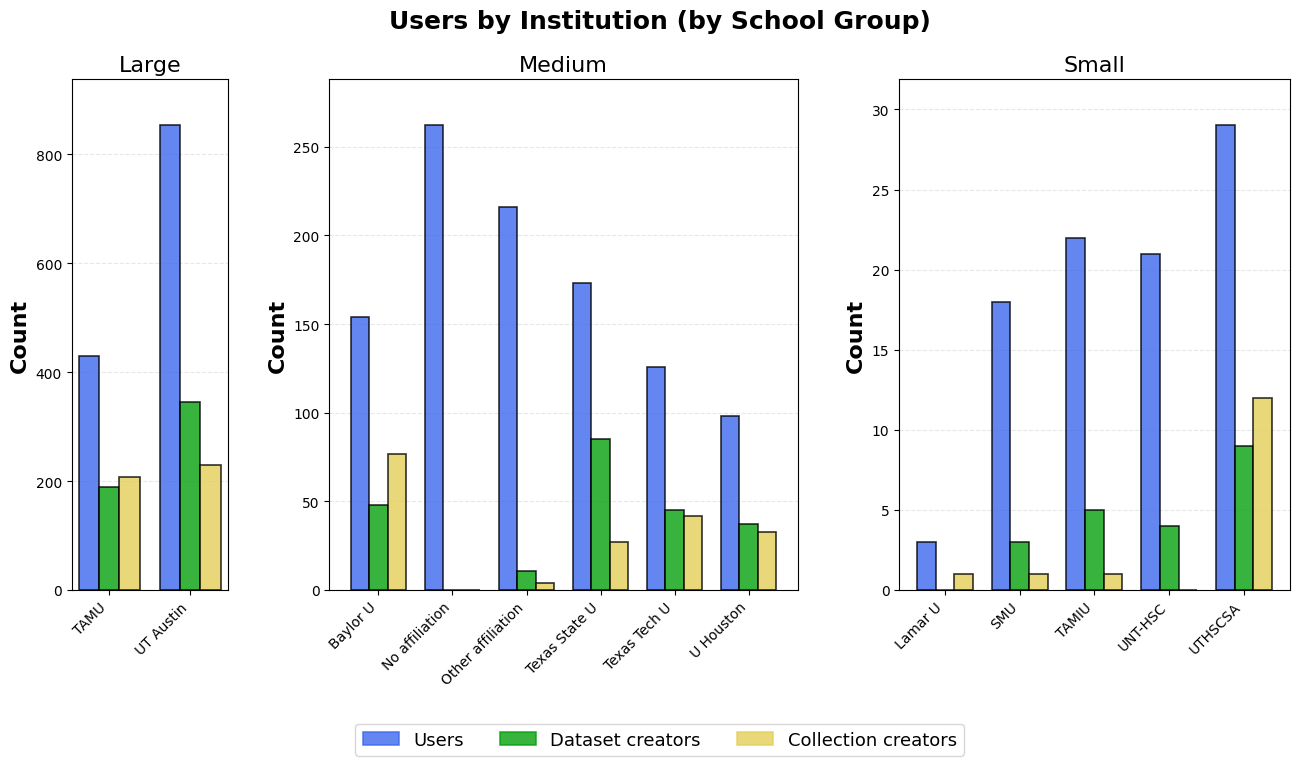

In [100]:
# Group by institution and count unique users
users_by_institution = users_real.groupby('Affiliation_Standardized').size().reset_index(name='total')
users_by_institution.rename(columns={'Affiliation_Standardized': 'institution'}, inplace=True)
users_by_institution['category'] = 'Users'

# Group by institution and count unique contactIdentifiers (contacts/depositors)
datasets_by_institution = datasets.groupby('institution_standardized')['dataset_depositor'].nunique().reset_index(name='total')
datasets_by_institution.rename(columns={'institution_standardized': 'institution'}, inplace=True)
datasets_by_institution['category'] = 'Dataset creators'

# Group by institution and count unique dataverses
dataverses_by_institution = dataverses_actual.groupby('institution_standardized')['contactIdentifier'].nunique().reset_index(name='total')
dataverses_by_institution.rename(columns={'institution_standardized': 'institution'}, inplace=True)
dataverses_by_institution['category'] = 'Collection creators'

# Combine all three
combined_by_institution = pd.concat([users_by_institution, datasets_by_institution, dataverses_by_institution], ignore_index=True)

# Condition subplot width based on number of schools
## Will ensure all bars are the same width regardless of how many are in a subplot
width_ratios = [len(schools) for schools in school_groups.values()]

###########################################
###             PLOT                    ###
###########################################

fig = plt.figure(figsize=(img_width, img_height))
gs = GridSpec(1, 3, width_ratios=width_ratios, wspace=0.3)

bar_width = 0.25
categories = ['Users', 'Dataset creators', 'Collection creators']
colors = {
    'Users': '#3c68ee',
    'Dataset creators': '#05A00D',
    'Collection creators': '#E4CF58'
}

for idx, (group_name, schools) in enumerate(school_groups.items()):
    ax = fig.add_subplot(gs[0, idx])
    
    # Filter data for this group
    group_data = combined_by_institution[combined_by_institution['institution'].isin(schools)]
    institutions_in_group = group_data['institution'].unique()
    
    x_pos = np.arange(len(institutions_in_group))
    # Increase y-axis lim above max bar height
    y_max = group_data['total'].max()
    ax.set_ylim(0, y_max*1.1)

    # Plot grouped bars for each category
    for i, category in enumerate(categories):
        category_data = group_data[group_data['category'] == category]
        
        # Create a mapping of institution to total for this category
        values = [category_data[category_data['institution'] == inst]['total'].values[0] 
                  if inst in category_data['institution'].values else 0 
                  for inst in institutions_in_group]
        
        ax.bar(x_pos + (i - 1) * bar_width, values, bar_width, 
               label=category, color=colors[category], edgecolor='black', linewidth=1.2, alpha=0.8)
        
        # # Add value labels on top of bars
        # for j, val in enumerate(values):
        #     if val > 0:
        #         ax.text(j + (i - 1) * bar_width, val + (y_max * 0.01), f'{int(val)}', 
        #                 ha='center', va='bottom', fontsize=10)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(institutions_in_group, rotation=45, ha='right')
    ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
    ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
    ax.set_title(group_name, fontsize=16) # This is 'Large', 'Medium', 'Small', not the entire fig title
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=legend_font, loc='upper right')

# Remove individual legends and create a single shared legend
for ax in fig.get_axes():
    ax.get_legend().remove()
## Create shared legend below the plots
handles = [plt.Rectangle((0, 0), 1, 1, color=colors[cat], edgecolor='black', linewidth=1.2, alpha=0.8) for cat in categories]
fig.legend(handles, categories, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3, fontsize=legend_font, frameon=True)

fig.suptitle('Users by Institution (by School Group)', fontsize=title_font, fontweight='bold', y=0.98)
plt.subplots_adjust(left=0.08, right=0.95, top=0.88, bottom=0.15)
plt.show()

## Slide 9: API Usage

Total number of API users: 525
.
Total number of API users without an affiliation: 88
.
Total number of API users without a confirmed email: 92
.
Total number of API users without a confirmed email: 70
.


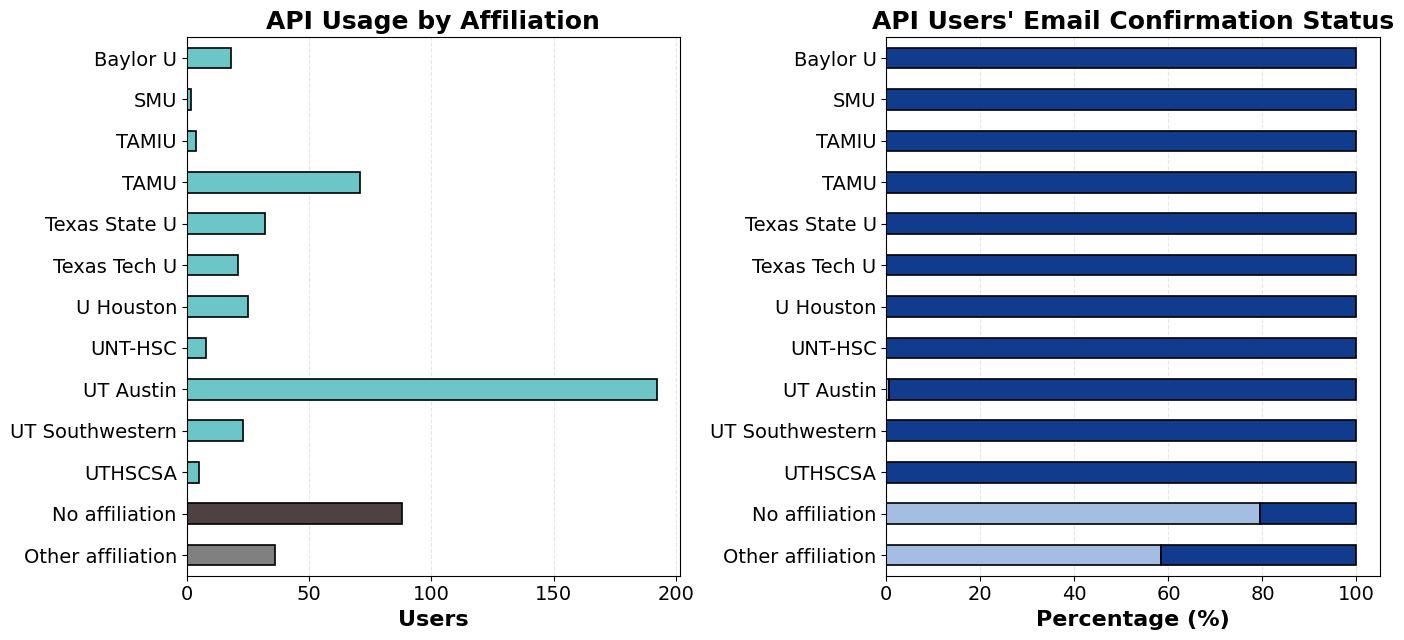

In [101]:
api_users = users_real[users_real['Last API Use'].notnull()]
print(f'Total number of API users: {len(api_users)}\n.')
api_users_no_affil = api_users[api_users['Affiliation'].isnull()]
print(f'Total number of API users without an affiliation: {len(api_users_no_affil)}\n.')
api_users_no_email = api_users[api_users['Email Confirmed'].isnull()]
print(f'Total number of API users without a confirmed email: {len(api_users_no_email)}\n.')
api_users_suspicious = api_users[(api_users['Email Confirmed'].isnull()) & (api_users['Affiliation'].isnull())]
print(f'Total number of API users without a confirmed email: {len(api_users_suspicious)}\n.')

api_users_plot = api_users.copy()
# Replace affiliations not in the list with 'Other affiliation'
api_users_plot['Affiliation_Standardized'] = api_users_plot['Affiliation_Standardized'].apply(
    lambda x: x if x in current_members_and_none else 'Other affiliation'
)

# Summarize API usage by institution
api_use_by_affiliation = api_users_plot['Last API Use'].groupby(api_users_plot['Affiliation_Standardized']).count()
current_members_sorted = sorted(current_members, reverse=True)
other = ['Other affiliation', 'No affiliation']
desired_order = other + current_members_sorted
api_use_by_affiliation = api_use_by_affiliation.reindex(desired_order)
api_use_by_affiliation = api_use_by_affiliation[api_use_by_affiliation > 0]

# Summarize API users by email confirmation status
api_users_plot['Email_Confirmed'] = api_users_plot['Email Confirmed'].notna() & (api_users_plot['Email Confirmed'] != '')
email_by_affiliation = api_users_plot.groupby(['Affiliation_Standardized', 'Email_Confirmed']).size().unstack()
email_by_affiliation_pct = email_by_affiliation.div(email_by_affiliation.sum(axis=1), axis=0) * 100
email_by_affiliation_pct = email_by_affiliation_pct.reindex(desired_order)
email_by_affiliation_pct = email_by_affiliation_pct.dropna(how='all')

###########################################
###             PLOT                    ###
###########################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, 6.5))

# LEFT: Usage by institution
## Set one color for all TDR members
chart_colors = {inst: '#6cc6c8' for inst in current_members}
chart_colors.update({
    'Other affiliation': '#808080',
    'No affiliation': '#4D4141'
})
colors = [chart_colors.get(inst, '#6cc6c8') for inst in api_use_by_affiliation.index]

api_use_by_affiliation.plot(kind='barh', ax=ax1, color=colors, edgecolor='black', linewidth=1.2)

## Labels, etc.
ax1.set_xlabel('Users', fontsize=axis_font, fontweight='bold')
ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax1.set_title('API Usage by Affiliation', fontsize=title_font, fontweight='bold')
ax1.tick_params(labelsize=tick_font)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# RIGHT: API usage by email confirmation 
colors_email = ["#a4bde2", "#113c8d"]
email_by_affiliation_pct.plot(kind='barh', stacked=True, ax=ax2, color=colors_email, edgecolor='black', linewidth=1.2)

## Labels, etc.
ax2.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title("API Users' Email Confirmation Status", fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.legend().remove()
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Slide 11: Cumulative Storage Size

4.0298822556589275
11.327992511142593
year_month_created
2017-04    1.734843e-07
2017-05    8.839961e-07
2017-09    1.623457e-05
2017-10    1.492989e-03
2017-11    1.493278e-03
               ...     
2026-01    2.618614e+00
2026-02    3.525745e+00
2026-03    4.006545e+00
2026-04    4.014221e+00
2026-05    4.029882e+00
Name: size_tb, Length: 103, dtype: float64
YearMonth
2017-01-01    0.000792
2017-03-01    0.000803
2017-04-01    0.002461
2017-05-01    0.002524
2017-06-01    0.026909
                ...   
2026-02-01    6.972418
2026-03-01    7.635421
2026-04-01    7.715233
2026-05-01    8.047617
2026-06-01    8.047618
Name: size_tb, Length: 113, dtype: float64


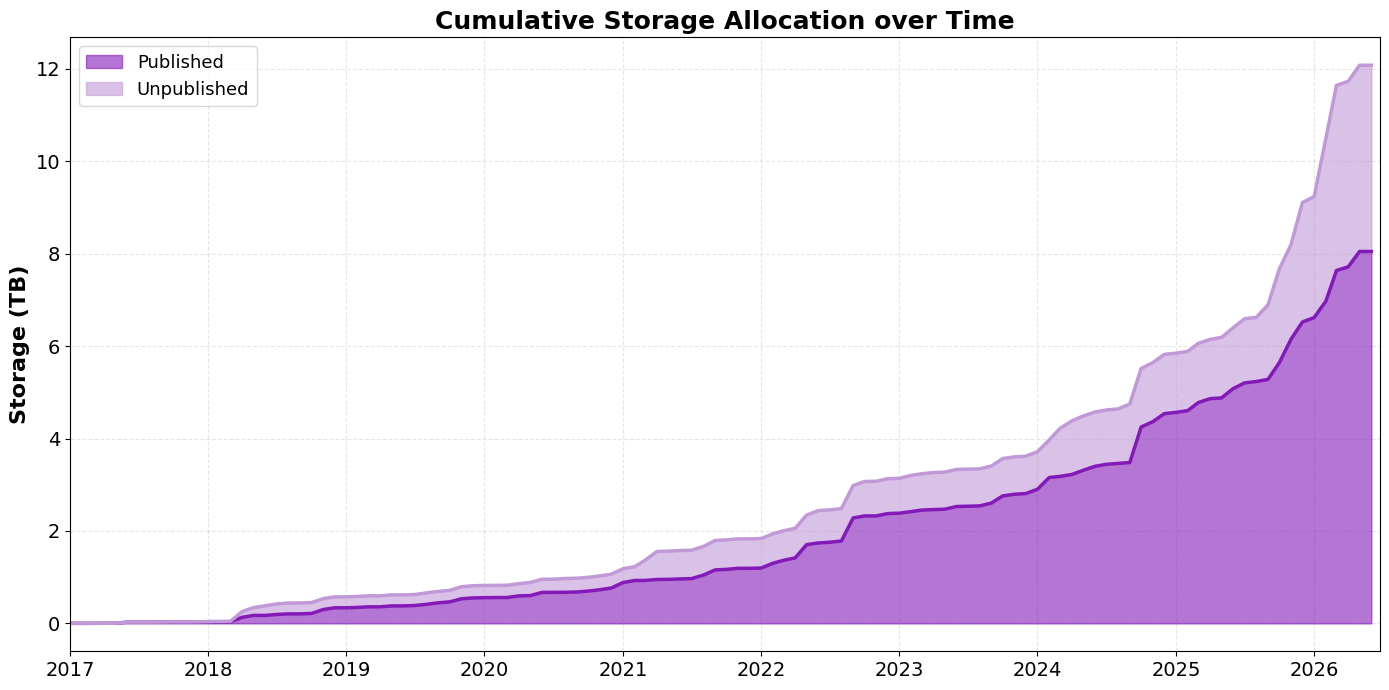

In [102]:
# Get data on unpublished datasets from TDL dump
datasets_copy = datasets.copy()
mask = datasets_copy['publicationDate'].isna() | (datasets_copy['publicationDate'].astype(str).str.strip() == '')
datasets_copy = datasets_copy[mask]
datasets_copy['size_tb'] = datasets_copy['contentSize_MB'] / (1024 **2)

total_tb = datasets_copy['contentSize_MB'].sum() / (1024 ** 2)
print(total_tb)
total_tb = datasets['contentSize_MB'].sum() / (1024 ** 2)
print(total_tb)

monthly_counts_datasets = datasets_copy.groupby('year_month_created')['size_tb'].sum()
cumulative_filesize_datasets = monthly_counts_datasets.cumsum()
print(cumulative_filesize_datasets)
## Convert period index to timestamp for plotting
# cumulative_filesize_datasets.index = cumulative_filesize_datasets.index.to_timestamp()

# Get data on published datasets' from file-level metadata
files_copy = files.copy()
files_copy['file_creation_date'] = pd.to_datetime(files_copy['file_creation_date'])
files_copy['size_gb'] = files_copy['file_size'] / (1024**3)
files_copy['size_tb'] = files_copy['size_gb'] / 1024
files_copy['YearMonth'] = files_copy['file_creation_date'].dt.to_period('M')
monthly_counts = files_copy.groupby('YearMonth')['size_tb'].sum()
cumulative_filesize = monthly_counts.cumsum()
## Convert period index to timestamp for plotting
cumulative_filesize.index = cumulative_filesize.index.to_timestamp()
print(cumulative_filesize)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Align the indices to ensure both series have the same dates
cumulative_filesize.index = pd.to_datetime(cumulative_filesize.index).to_period('M').to_timestamp()
cumulative_filesize_datasets.index = pd.to_datetime(cumulative_filesize_datasets.index).to_period('M').to_timestamp()

all_dates = cumulative_filesize.index.union(cumulative_filesize_datasets.index)
files_aligned = cumulative_filesize.reindex(all_dates, method='ffill').fillna(0)
datasets_aligned = cumulative_filesize_datasets.reindex(all_dates, method='ffill').fillna(0)

# Plot stacked area chart
ax.fill_between(files_aligned.index, 0, files_aligned.values, 
                alpha=0.6, color="#831ab8", label='Published')
ax.fill_between(datasets_aligned.index, files_aligned.values, 
                files_aligned.values + datasets_aligned.values, 
                alpha=0.6, color="#c299d7", label='Unpublished')

# Plot the lines on top
ax.plot(files_aligned.index, files_aligned.values, 
        color="#831ab8", linewidth=2.5)
ax.plot(datasets_aligned.index, files_aligned.values + datasets_aligned.values, 
        color="#c299d7", linewidth=2.5)

# Customize the plot
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), today_pd)
ax.set_ylabel('Storage (TB)', fontsize=axis_font, fontweight='bold')
ax.set_title('Cumulative Storage Allocation over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper left')

plt.tight_layout()
plt.show()

## Slide 12: Storage Allocation by Institution

                          unpublished_size  published_size    total_size
institution_standardized                                                
UTHSCSA                       7.663810e+05    8.880422e+08  8.888086e+08
UT Southwestern               1.409297e+12    1.097083e+12  2.506379e+12
UT Austin                     8.433378e+11    3.738959e+12  4.582297e+12
UNT-HSC                       1.007900e+07    2.392089e+10  2.393097e+10
U Houston                     1.014204e+11    3.617572e+11  4.631776e+11
Texas Tech U                  1.348954e+10    4.169110e+10  5.518064e+10
Texas State U                 1.454081e+12    2.073532e+11  1.661435e+12
TAMU Galveston                5.998753e+06    5.877683e+09  5.883682e+09
TAMU                          4.299581e+11    1.869651e+12  2.299609e+12
TAMIU                         4.523244e+10    3.037237e+11  3.489562e+11
SMU                           6.975513e+08    8.880693e+10  8.950448e+10
Other affiliation             0.000000e+00    3.199

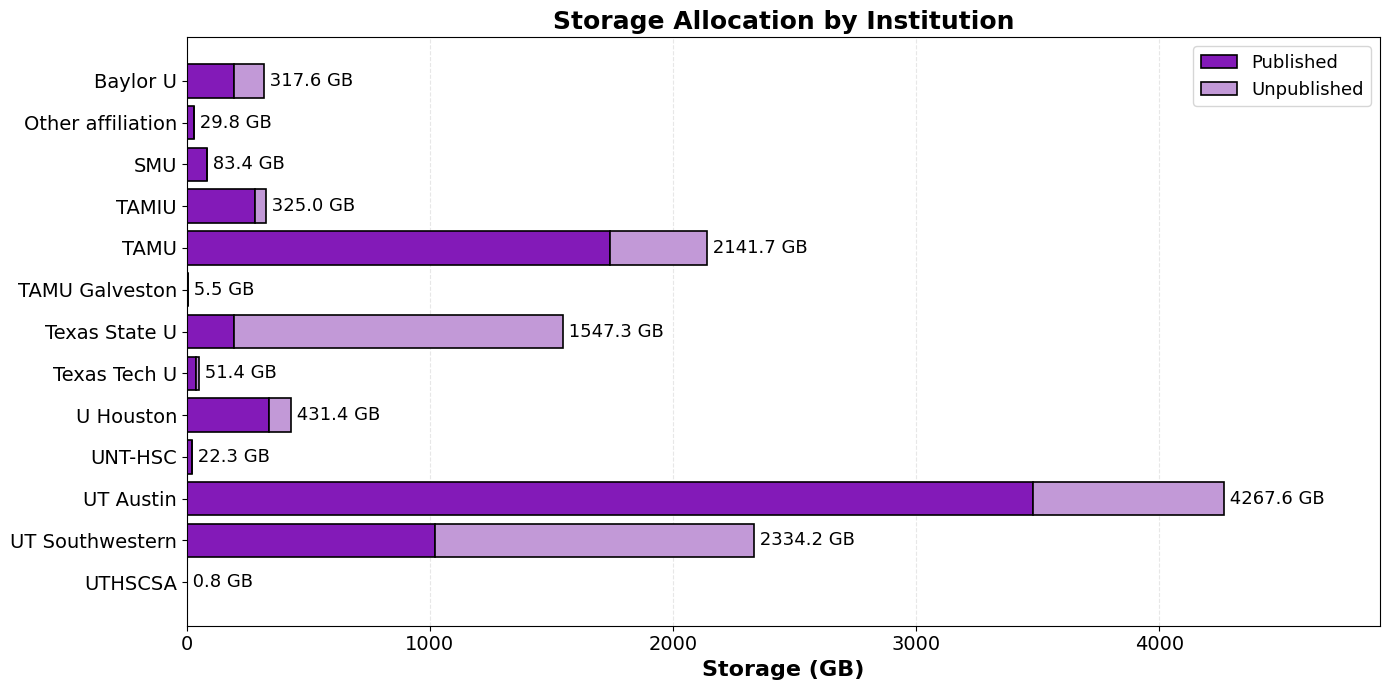

In [103]:
# Get published datasets total size (in bytes)
datasets_published = datasets_published_df.copy()
published_size = datasets_published.groupby('institution_standardized')['dataset_size'].sum().reset_index(name='published_size')

# Get all datasets total size (in MB, convert to bytes for consistency)
datasets_unpublished = datasets_unpublished_df.copy()
unpublished_size = datasets_unpublished.groupby('institution_standardized')['contentSize_MB'].sum().reset_index(name='unpublished_size')
unpublished_size['unpublished_size'] = unpublished_size['unpublished_size'] * (1024**2)

# Merge on institution
merged = unpublished_size.merge(published_size, on='institution_standardized', how='outer').fillna(0)
merged = merged[merged['institution_standardized'] != 0]
merged = merged.set_index('institution_standardized')

# Calculate total size
merged['total_size'] = merged['unpublished_size'] + merged['published_size']

merged = merged.sort_index(ascending=False)

print(merged)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))
y_pos = np.arange(len(merged))

# Stacked bars: published on bottom, unpublished on top
ax.barh(y_pos, merged['published_size'].values / (1024**3), 
        label='Published', color='#831ab8', edgecolor='black', linewidth=1.2)
ax.barh(y_pos, merged['unpublished_size'].values / (1024**3), 
        left=merged['published_size'].values / (1024**3),
        label='Unpublished', color='#c299d7', edgecolor='black', linewidth=1.2)

# Add collective size labels
for i, total in enumerate(merged['total_size'].values):
    if total > 0:
        size_gb = total / (1024**3)
        ax.text(size_gb, i, f' {size_gb:.1f} GB', ha='left', va='center', fontsize=13)

# Labels, etc.
ax.set_yticks(y_pos)
ax.set_yticklabels(merged.index)
ax.set_xlabel('Storage (GB)', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=16, fontweight='bold')
ax.set_title('Storage Allocation by Institution', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper right')

# Add padding to x-axis to accommodate labels
x_max = merged['total_size'].max() / (1024**3)
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Alternative to Slide 12

This is a faceted series of bar plots divided by school size and showing absolute count of datasets in different size bins.

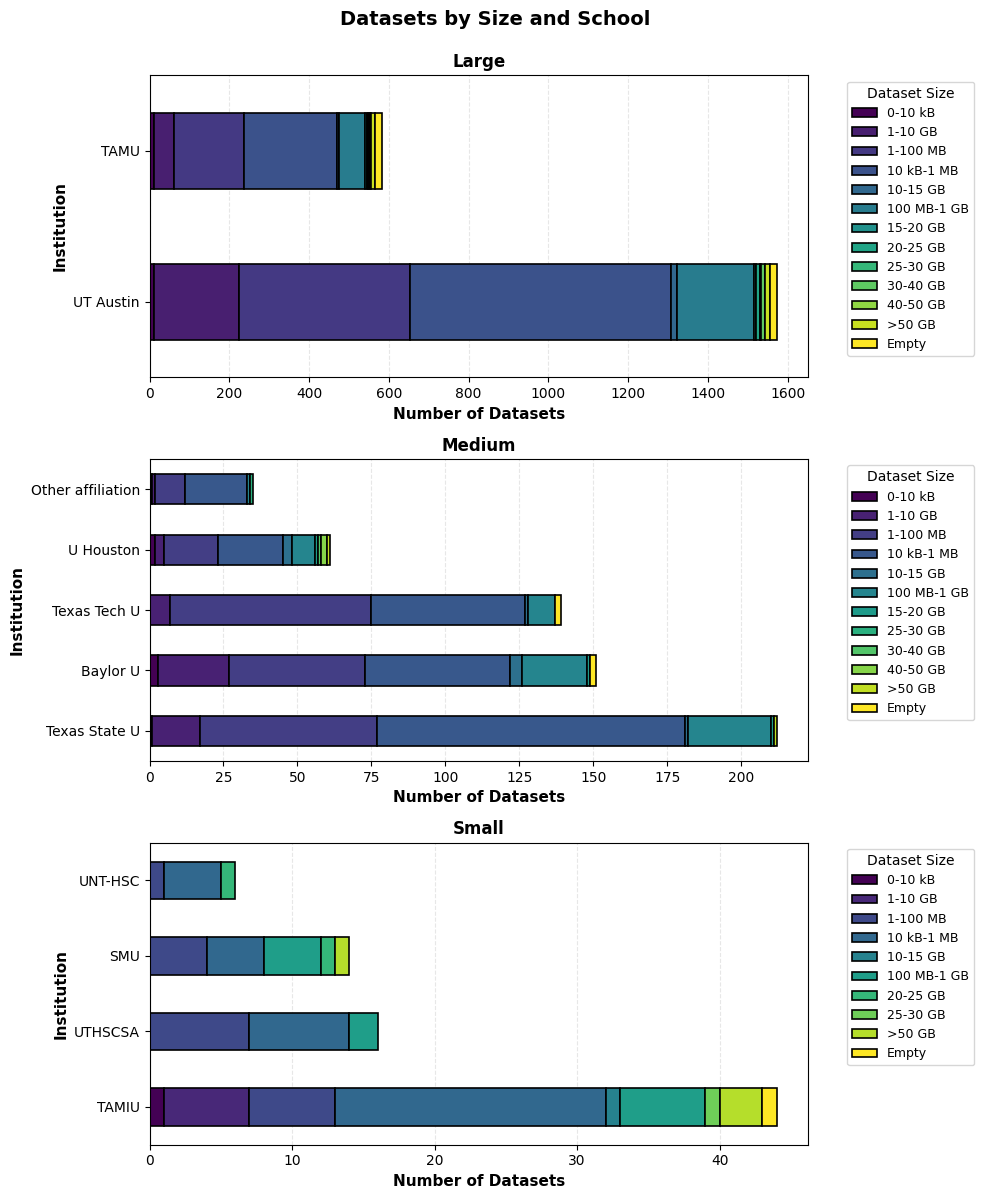

In [104]:
#| echo: false
#| warning: false

datasets_plot = datasets.copy()
datasets_by_size_school = datasets_plot.groupby(['institution_standardized', 'dataset_size_bin']).size().reset_index(name='count')

# Create the figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

for ax, (group_name, schools) in zip(axes, school_groups.items()):
    # Filter data for this group
    group_data = datasets_by_size_school[datasets_by_size_school['institution_standardized'].isin(schools)]
    
    # Pivot to get institutions as rows and size_bins as columns
    pivot_data = group_data.pivot(index='institution_standardized', columns='dataset_size_bin', values='count').fillna(0)
    
    # Sort by total count
    pivot_data['Total'] = pivot_data.sum(axis=1)
    pivot_data = pivot_data.sort_values('Total', ascending=False)
    pivot_data = pivot_data.drop('Total', axis=1)
    
    # Create stacked bar chart
    colors = plt.cm.viridis(np.linspace(0, 1, len(pivot_data.columns)))
    pivot_data.plot(kind='barh', stacked=True, ax=ax, edgecolor='black', color=colors, linewidth=1.2)
    
    ax.set_xlabel('Number of Datasets', fontsize=11, fontweight='bold')
    ax.set_ylabel('Institution', fontsize=11, fontweight='bold')
    ax.set_title(group_name, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(title='Dataset Size', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

fig.suptitle('Datasets by Size and School', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

## Slide 13: Dataset Count and Storage Size by Dataset Size Bin


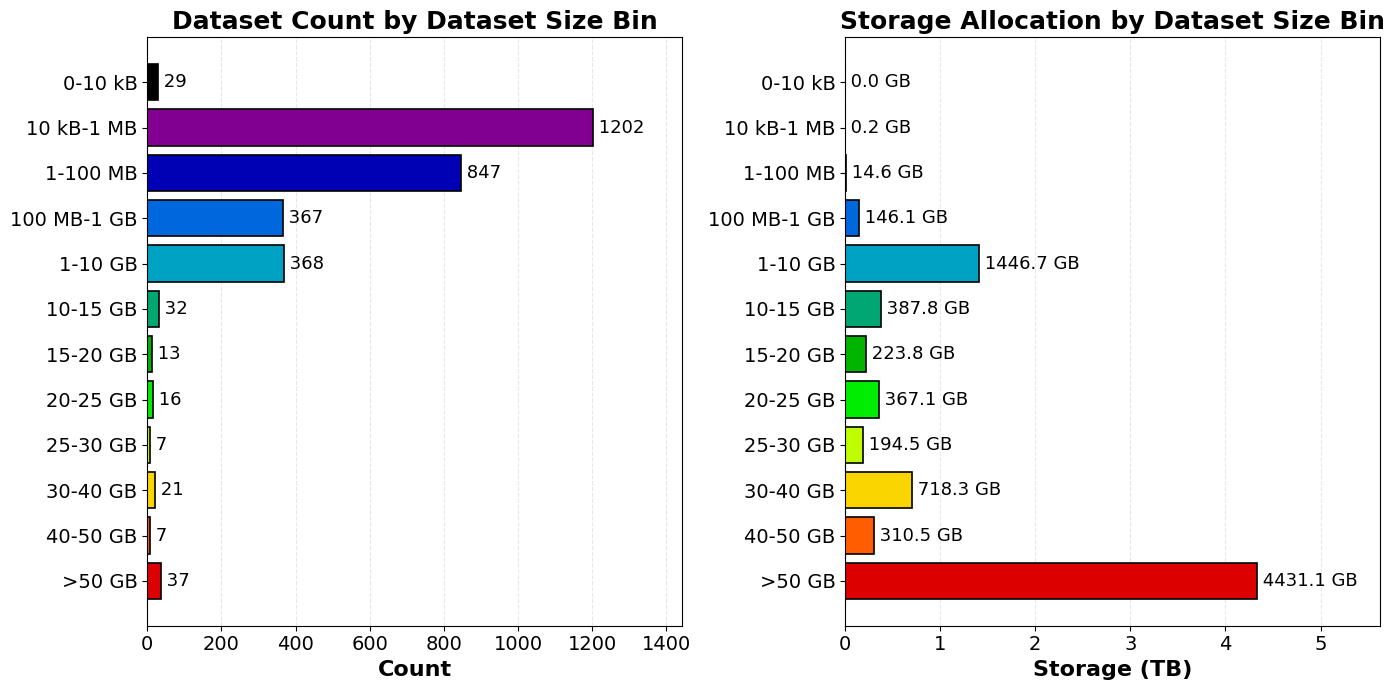

In [105]:
# Counting datasets in each size bin
datasets_plot = datasets.copy()
datasets_by_size_tdr = datasets_plot.groupby(['dataset_size_bin']).size().reset_index(name='count')
datasets_by_size_tdr = datasets_by_size_tdr.set_index('dataset_size_bin')
datasets_by_size_tdr = datasets_by_size_tdr.reindex(bin_labels[::-1], fill_value=0)

# Counting total storage size in each size bin
datasets_plot = datasets.copy()
datasets_size_sum = datasets_plot.groupby('dataset_size_bin')['dataset_size'].sum().reset_index(name='total_size')
datasets_size_sum = datasets_size_sum.set_index('dataset_size_bin')
datasets_size_sum = datasets_size_sum.reindex(bin_labels[::-1], fill_value=0)
datasets_size_sum['total_size_tb'] = datasets_size_sum['total_size'] / (1024**4)


datasets_by_size_school = datasets_plot.groupby(['institution_standardized', 'dataset_size_bin']).size().reset_index(name='count')
pivot_df_count = datasets_by_size_school.pivot(index='institution_standardized', columns='dataset_size_bin', values='count').fillna(0)
pivot_df_count = pivot_df_count.reindex(columns=bin_labels, fill_value=0)
pivot_pct_count = pivot_df_count.div(pivot_df_count.sum(axis=1), axis=0) * 100
all_data_count = pivot_pct_count.sort_index(ascending=False)

datasets_by_size_school_sum = datasets_plot.groupby(['institution_standardized', 'dataset_size_bin']).agg(
    total_size=('dataset_size', 'sum')
).reset_index()
pivot_df_size = datasets_by_size_school_sum.pivot(index='institution_standardized', columns='dataset_size_bin', values='total_size').fillna(0)
pivot_df_size = pivot_df_size.reindex(columns=bin_labels, fill_value=0)
pivot_pct_size = pivot_df_size.div(pivot_df_size.sum(axis=1), axis=0) * 100
all_data_size = pivot_pct_size.sort_index(ascending=False)

###########################################
###             PLOT                    ###
###########################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))

colors = plt.cm.nipy_spectral(np.linspace(0.9, 0, len(all_data_count.columns)))

y_pos = np.arange(len(datasets_by_size_tdr))

ax1.barh(y_pos, datasets_by_size_tdr['count'].values, 
        color=colors, edgecolor='black', linewidth=1.2)

# Add value labels
for i, count in enumerate(datasets_by_size_tdr['count'].values):
    if count > 0:  # Only show label if count > 0
        ax1.text(count, i, f' {int(count)}', ha='left', va='center', fontsize=13)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(datasets_by_size_tdr.index)
ax1.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax1.set_title('Dataset Count by Dataset Size Bin', fontsize=title_font, fontweight='bold')
ax1.tick_params(labelsize=tick_font)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add padding for labels
x_max = datasets_by_size_tdr['count'].max()
ax1.set_xlim(0, x_max * 1.2)

y_pos = np.arange(len(datasets_size_sum))

ax2.barh(y_pos, datasets_size_sum['total_size_tb'].values, 
        color=colors, edgecolor='black', linewidth=1.2)

# Add value labels (already in GB)
for i, size_tb in enumerate(datasets_size_sum['total_size_tb'].values):
    if size_tb > 0:
        size_gb = size_tb * 1024  # Convert TB to GB
        ax2.text(size_tb, i, f' {size_gb:.1f} GB', ha='left', va='center', fontsize=13)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(datasets_size_sum.index)
ax2.set_xlabel('Storage (TB)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title('Storage Allocation by Dataset Size Bin', fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add padding for labels
x_max = datasets_size_sum['total_size_tb'].max()
ax2.set_xlim(0, x_max * 1.3)

# Add some space between plots
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

## Slide 14: Relative proportions of dataset count and storage by dataset size bin

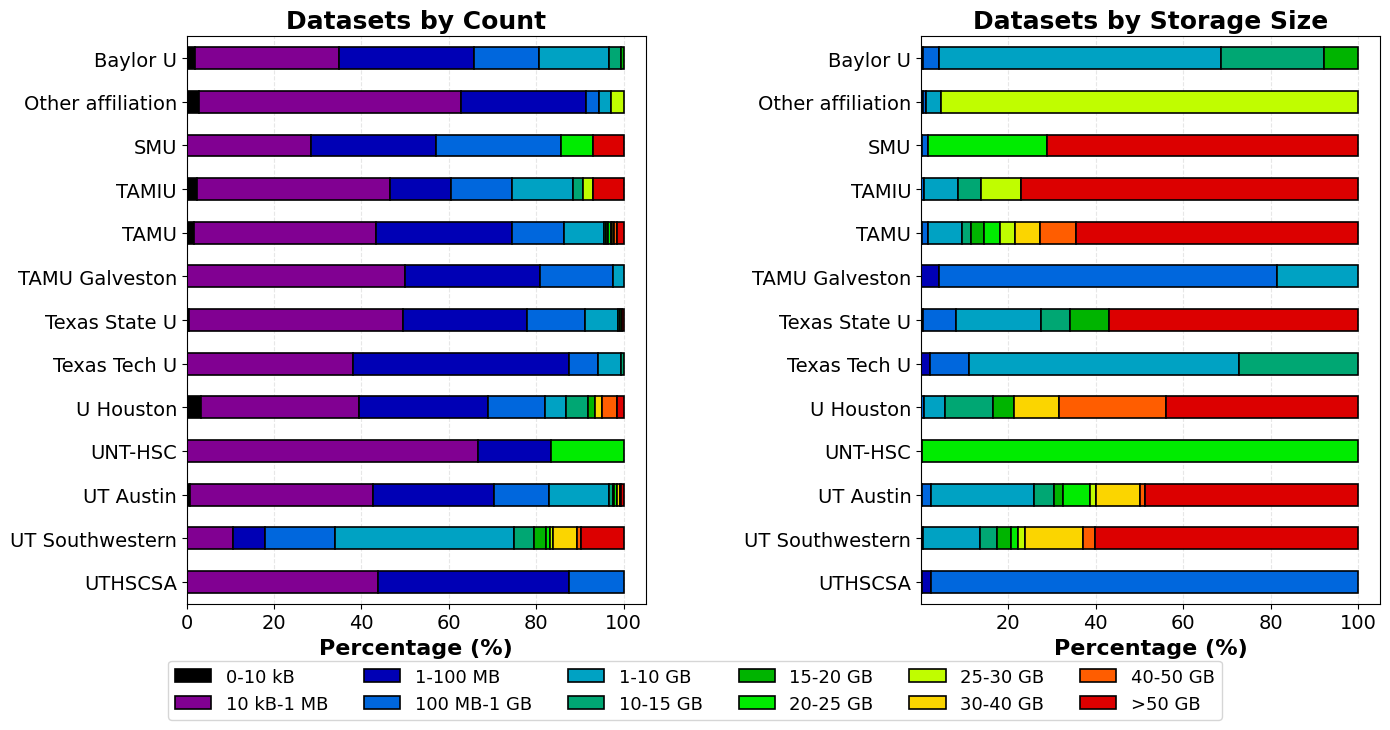

In [106]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))

# Colors (same for both)
colors = plt.cm.nipy_spectral(np.linspace(0, 0.9, len(all_data_count.columns)))

# LEFT: Count-based
all_data_count.plot(kind='barh', stacked=True, ax=ax1, edgecolor='black', color=colors, linewidth=1.2, legend=False)
ax1.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax1.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax1.set_title('Datasets by Count', fontsize=title_font, fontweight='bold')
ax1.tick_params(labelsize=tick_font)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# RIGHT: Storage-based
all_data_size.plot(kind='barh', stacked=True, ax=ax2, edgecolor='black', color=colors, linewidth=1.2, legend=False)
ax2.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title('Datasets by Storage Size', fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Create shared legend below both plots
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, title='', loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), ncol=6, fontsize=legend_font, 
           title_fontsize=13, frameon=True)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.subplots_adjust(wspace=0.6)
plt.show()

## Unused complement to Slide 15

This is a monochromatic horizontal bar graph that shows the per dataset storage (i.e. dividing the total number of storage allocation by the total number of datasets). This creates a mathematical average but is unlikely to reflect a genuine "average" dataset (median).

   institution_standardized  count
0                  Baylor U    200
1         Other affiliation     36
2                       SMU     14
3                     TAMIU     51
4                      TAMU    734
5            TAMU Galveston     44
6             Texas State U    265
7              Texas Tech U    200
8                 U Houston     84
9                   UNT-HSC      6
10                UT Austin   2056
11          UT Southwestern    161
12                  UTHSCSA     22


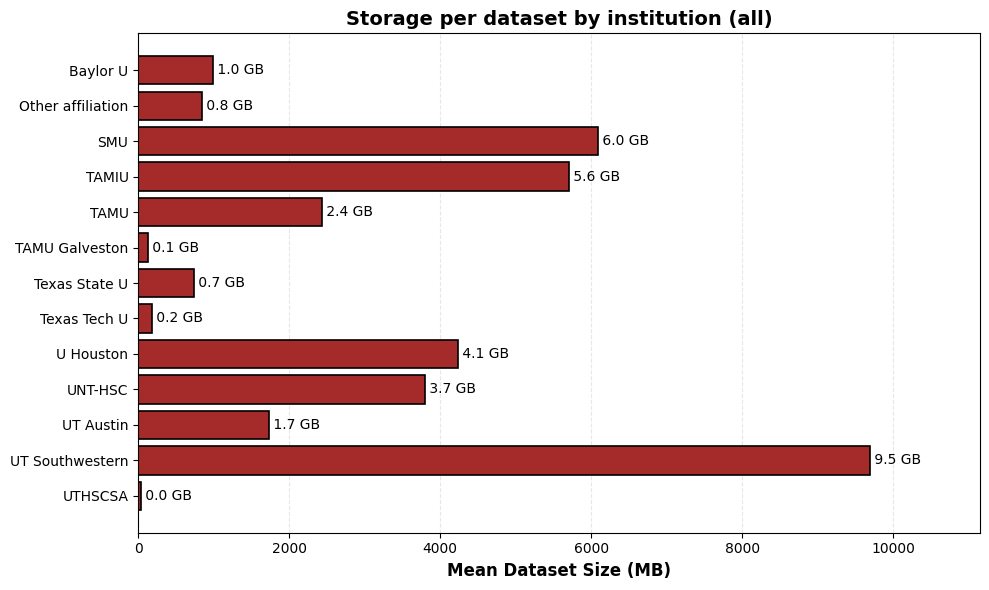

In [107]:
datasets_plot = datasets.copy()

# Get total size per institution
datasets_size_sum = datasets_plot.groupby('institution_standardized')['dataset_size_MB'].sum().reset_index(name='total_size')

# Get count of datasets per institution
datasets_count = datasets_plot.groupby('institution_standardized').size().reset_index(name='count')
print(datasets_count)

# Merge and calculate average
datasets_avg = datasets_size_sum.merge(datasets_count, on='institution_standardized')
datasets_avg['avg_size'] = datasets_avg['total_size'] / datasets_avg['count']

# Set index and sort
datasets_avg = datasets_avg.set_index('institution_standardized')
datasets_avg = datasets_avg.sort_index(ascending=False)

# Create single plot
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(datasets_avg))

ax.barh(y_pos, datasets_avg['avg_size'].values, 
        color='brown', edgecolor='black', linewidth=1.2)

# Add value labels (convert to GB for readability)
for i, size in enumerate(datasets_avg['avg_size'].values):
    if size > 0:
        size_gb = size / 1024  # Convert MB to GB
        ax.text(size, i, f' {size_gb:.1f} GB', ha='left', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(datasets_avg.index)
ax.set_xlabel('Mean Dataset Size (MB)', fontsize=12, fontweight='bold')
ax.set_ylabel('', fontsize=12, fontweight='bold')
ax.set_title('Storage per dataset by institution (all)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add padding for labels
x_max = datasets_avg['avg_size'].max()
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Slide 16: Cumulative Collections Over Time

YearMonth_published
2017-01       1
2017-03       5
2017-04       7
2017-05      12
2017-06      20
           ... 
2026-01    1046
2026-02    1061
2026-03    1067
2026-04    1076
2026-05    1088
Length: 111, dtype: int64


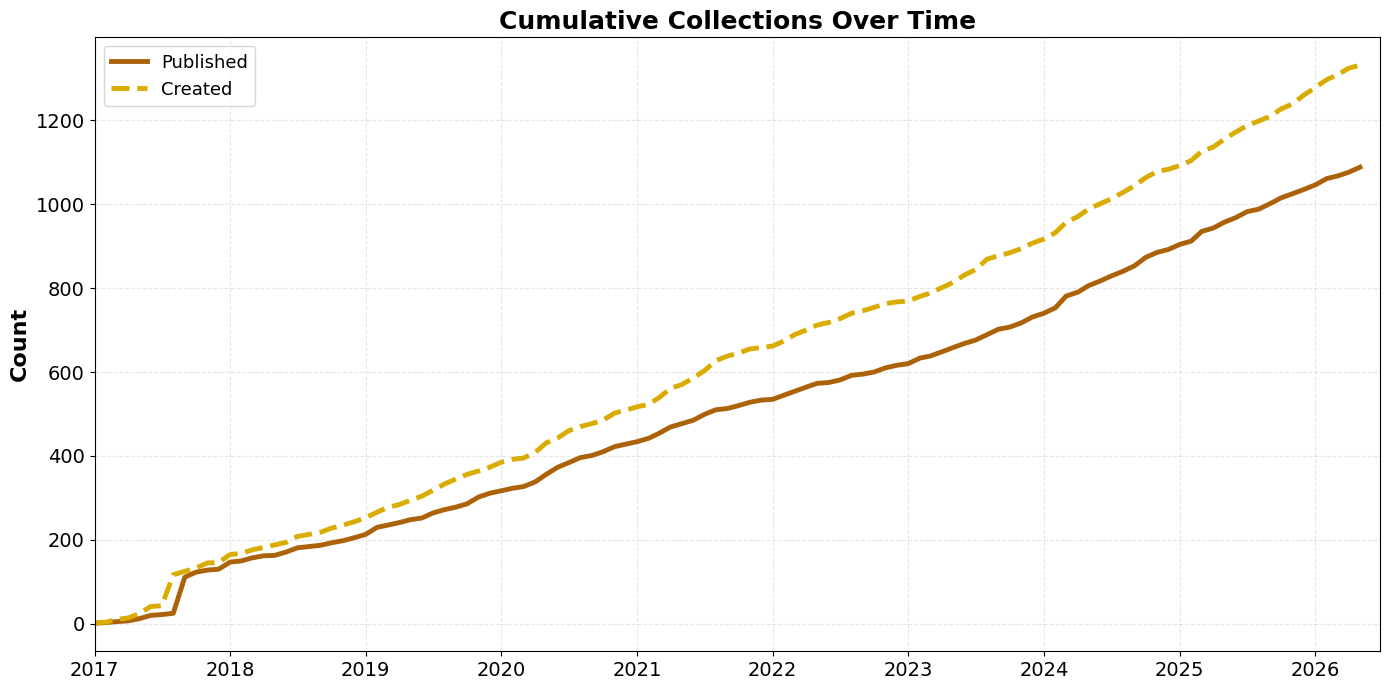

In [108]:
#| echo: false
#| warning: false

# Count records per month - published
monthly_counts_published = dataverses_actual.groupby('YearMonth_published').size()
# Count records per month - creation
monthly_counts_creation = dataverses_actual.groupby('year_month_created').size()

# Convert to cumulative sum
cumulative_counts_published = monthly_counts_published.cumsum()
cumulative_counts_creation = monthly_counts_creation.cumsum()
print(cumulative_counts_published)

## Convert period index to timestamp for plotting
cumulative_counts_published.index = pd.to_datetime(cumulative_counts_published.index)
cumulative_counts_creation.index = pd.to_datetime(cumulative_counts_creation.index)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Plot both lines
ax.plot(cumulative_counts_published.index, cumulative_counts_published.values, 
        color="#AB6209", linewidth=3.5, label='Published')

ax.plot(cumulative_counts_creation.index, cumulative_counts_creation.values, 
        color="#DBAC00", linewidth=3.5, linestyle='dashed', label='Created')

# Customize the plot
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), today_pd)
ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Cumulative Collections Over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=legend_font, loc='upper left')

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Slide 17: Collection Publication & Creation by Institution

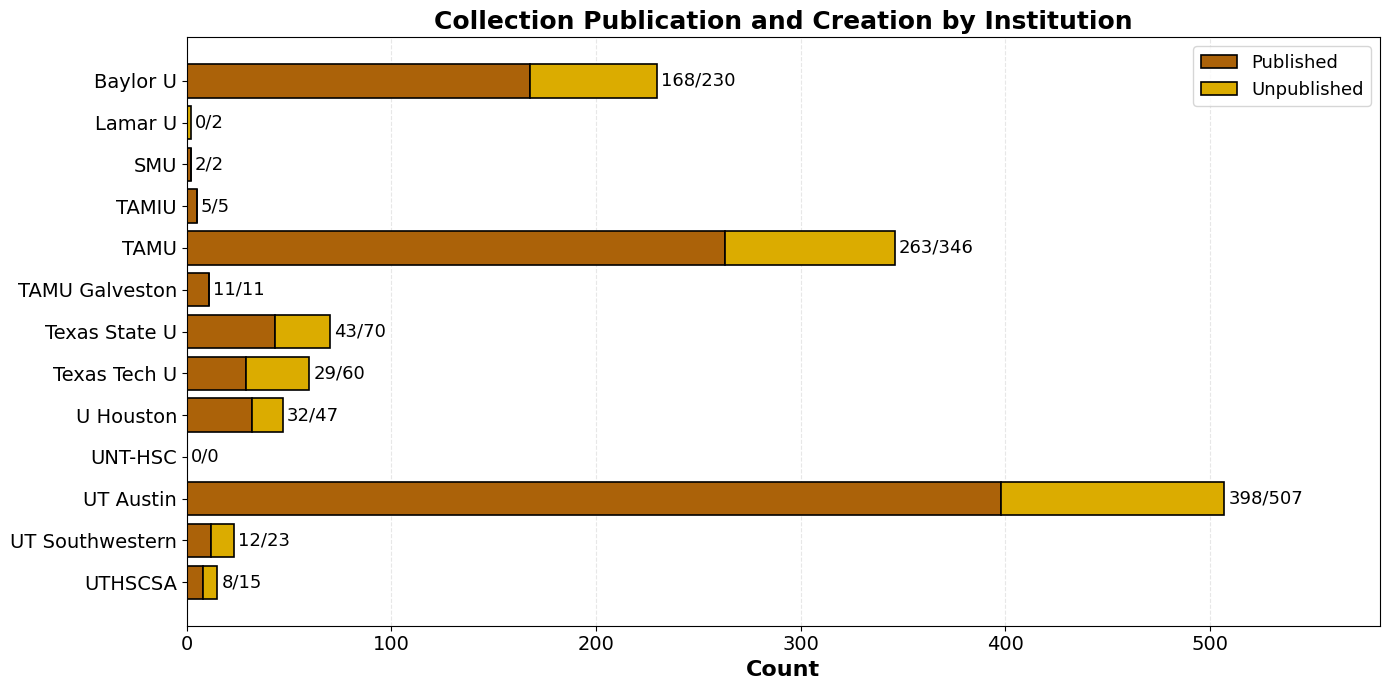

In [109]:
dataverses_plot = dataverses_actual.copy()

# Create published and unpublished counts
dataverses_released = dataverses_plot[dataverses_plot['released'] == 'Yes'].groupby('institution_standardized').size()
dataverses_unreleased = dataverses_plot[dataverses_plot['released'] == 'No'].groupby('institution_standardized').size()

# Reindex to current_members and sort descending
schools_sorted = sorted(current_members, reverse=True)
released_data = dataverses_released.reindex(schools_sorted, fill_value=0)
unreleased_data = dataverses_unreleased.reindex(schools_sorted, fill_value=0)
total_data = released_data + unreleased_data

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

y_pos = np.arange(len(schools_sorted))

# Plot stacked bars (released on left, unreleased on right)
ax.barh(y_pos, released_data.values, label='Published', 
        color="#AB6209", edgecolor='black', linewidth=1.2)
ax.barh(y_pos, unreleased_data.values, 
        left=released_data.values, label='Unpublished', 
        color="#DBAC00", edgecolor='black', linewidth=1.2)

# Add P/U labels to the right of bars
label_offset = 2
for i, (released_val, unreleased_val) in enumerate(zip(released_data.values, unreleased_data.values)):
    total_width = released_val + unreleased_val
    ax.text(total_width + label_offset, i, f'{int(released_val)}/{int(total_width)}', 
            ha='left', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(schools_sorted)
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Collection Publication and Creation by Institution', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper right')

# Increase x-axis max for label space
x_max = total_data.max()
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Alternative to Slide 17

This is a faceted series of bar graphs.

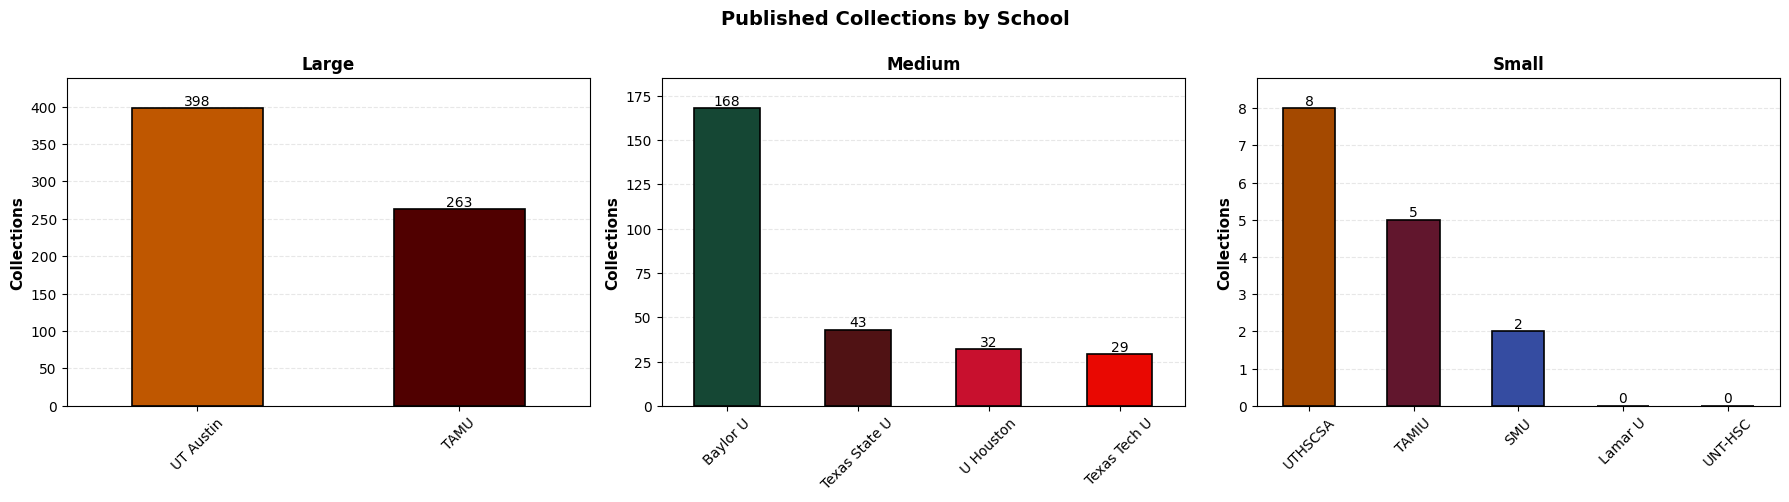

In [110]:
dataverses_plot = dataverses_published.copy()
dataverses_by_affiliation = dataverses_plot['institution_standardized'].groupby(dataverses_plot['institution_standardized']).count().reindex(current_members, fill_value=0)


# Create the figure with 1 row x 3 columns (changed from 3 rows x 1 column)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (group_name, schools) in zip(axes, school_groups.items()):
    # Filter data for this group
    group_data = dataverses_by_affiliation[dataverses_by_affiliation.index.isin(schools)].sort_values(ascending=False)
    
    colors = [school_colors.get(aff, 'gray') for aff in group_data.index]
    
    # Plot vertical bar chart
    group_data.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=1.2)
    
    # Add value labels on top of bars
    for i, (idx, value) in enumerate(group_data.items()):
        ax.text(i, value, f'{int(value)}', ha='center', va='bottom', fontsize=10)
    
    ax.set_ylabel('Collections', fontsize=11, fontweight='bold')
    ax.set_xlabel('', fontsize=11, fontweight='bold')
    ax.set_title(group_name, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    
    # Rotate x-axis labels for readability
    ax.tick_params(axis='x', rotation=45)

    # Increase y-axis max
    y_max = group_data.max()
    ax.set_ylim(0, y_max * 1.1)  # 1.1 = 10% padding

fig.suptitle('Published Collections by School', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()

## Slide 19: Cumulative Datasets Over Time

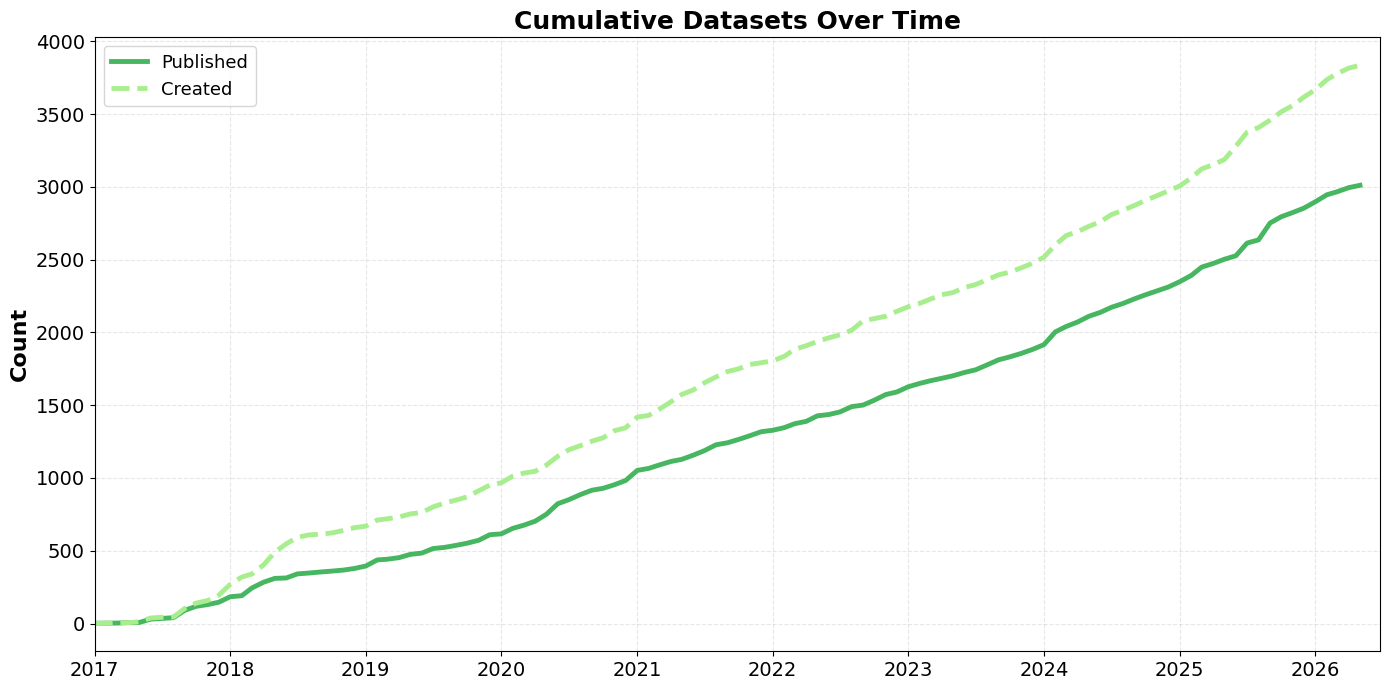

In [111]:
#| echo: false
#| warning: false

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Define colors and line styles for each category
styles = {
    'Created': {'color': "#a9ee8e", 'linestyle': 'dashed', 'linewidth': 3.5},
    'Published': {'color': "#47b661", 'linestyle': 'solid', 'linewidth': 3.5}
}

for category in dataset_concat['category'].unique():
    data = dataset_concat[dataset_concat['category'] == category]
    style = styles[category]
    
    ax.plot(data['year_month'], data['total'], 
            label=category,
            color=style['color'], 
            linestyle=style['linestyle'],
            linewidth=style['linewidth'])

# Customize the plot
ax.set_xlabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlim(pd.Timestamp('2017-01-01'), today_pd)
ax.set_ylabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Cumulative Datasets Over Time', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=legend_font, loc='upper left')

plt.tight_layout()
plt.show()

## Slide 20: Dataset Publication & Creation by Institution

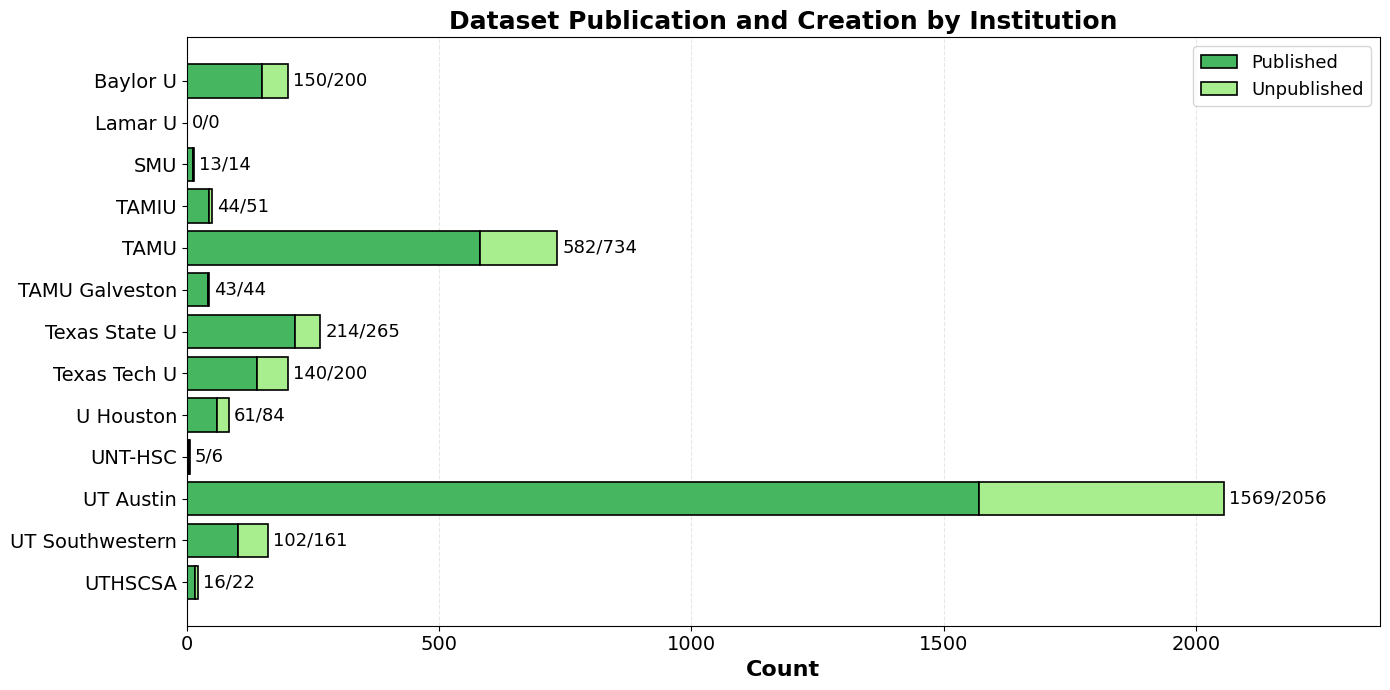

In [112]:
# Filter data for all current members and sort alphabetically
datasets_created_by_affiliation = datasets['institution_standardized'].groupby(datasets['institution_standardized']).count().reindex(current_members, fill_value=0)
datasets_created_by_affiliation = datasets_created_by_affiliation.sort_index(ascending=False)

datasets_published_by_affiliation = datasets_published_df['institution_standardized'].groupby(datasets_published_df['institution_standardized']).count().reindex(current_members, fill_value=0)
datasets_published_by_affiliation = datasets_published_by_affiliation.sort_index(ascending=False)

schools_sorted = sorted(current_members, reverse=True)

created_data = datasets_created_by_affiliation.reindex(schools_sorted, fill_value=0)
published_data = datasets_published_by_affiliation.reindex(schools_sorted, fill_value=0)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

y_pos = np.arange(len(schools_sorted))

# Plot stacked bars (published on left, created on right)
ax.barh(y_pos, published_data.values, label='Published', 
        color="#47b661", edgecolor='black', linewidth=1.2)
ax.barh(y_pos, created_data.values - published_data.values, 
        left=published_data.values, label='Unpublished', 
        color="#a9ee8e", edgecolor='black', linewidth=1.2)

# Add P/C labels to the right of bars
label_offset = 10  # Fixed distance from end of bar
for i, (created_val, published_val) in enumerate(zip(created_data.values, published_data.values)):
    total_width = created_val
    ax.text(total_width + label_offset, i, f'{int(published_val)}/{int(created_val)}', 
            ha='left', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(schools_sorted)
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Dataset Publication and Creation by Institution', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=legend_font, loc='upper right')

# Increase x-axis max for label space
x_max = created_data.max()
ax.set_xlim(0, x_max * 1.15)

plt.tight_layout()
plt.show()

## Alternative to Slide 20

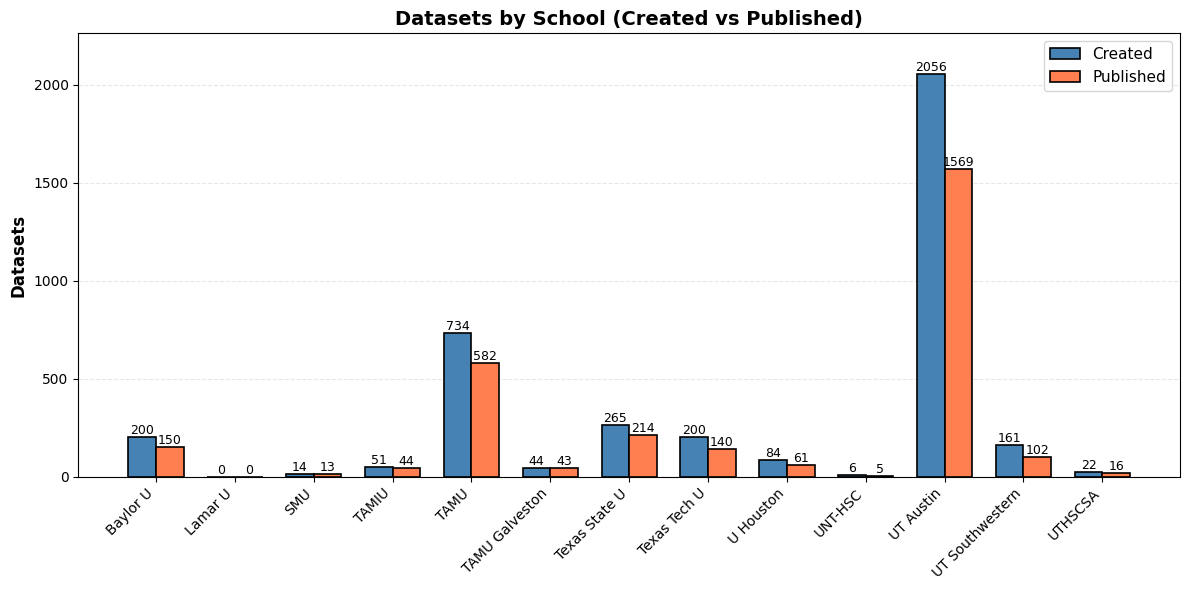

In [113]:
#| echo: false
#| warning: false

# Filter data for all current members and sort alphabetically
schools_sorted = sorted(current_members)

created_data = datasets_created_by_affiliation.reindex(schools_sorted, fill_value=0)
published_data = datasets_published_by_affiliation.reindex(schools_sorted, fill_value=0)

# Create single plot
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(schools_sorted))
bar_width = 0.35

# Plot grouped bars
ax.bar(x_pos - bar_width/2, created_data.values, bar_width, 
       label='Created', color='steelblue', edgecolor='black', linewidth=1.2)
ax.bar(x_pos + bar_width/2, published_data.values, bar_width, 
       label='Published', color='coral', edgecolor='black', linewidth=1.2)

# Add value labels on top of bars
for i, (created_val, published_val) in enumerate(zip(created_data.values, published_data.values)):
    ax.text(i - bar_width/2, created_val, f'{int(created_val)}', 
            ha='center', va='bottom', fontsize=9)
    ax.text(i + bar_width/2, published_val, f'{int(published_val)}', 
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x_pos)
ax.set_xticklabels(schools_sorted, rotation=45, ha='right')
ax.set_ylabel('Datasets', fontsize=12, fontweight='bold')
ax.set_xlabel('', fontsize=12, fontweight='bold')
ax.set_title('Datasets by School (Created vs Published)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend(fontsize=11, loc='upper right')

# Increase y-axis max for label space
y_max = max(created_data.max(), published_data.max())
ax.set_ylim(0, y_max * 1.1)

plt.tight_layout()
plt.show()

## Alternative to Slide 20

This is the same as the above, just faceted into separate subplots by school size.

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\1348718988.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


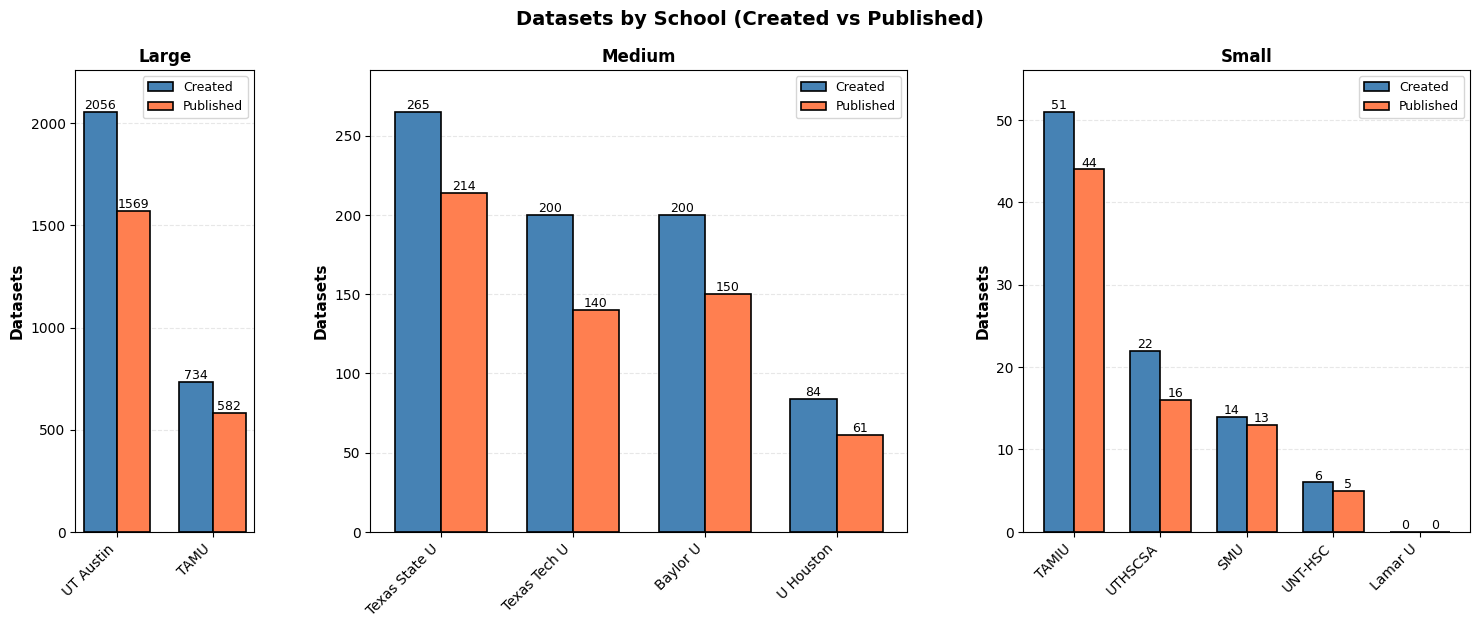

In [114]:
# Calculate width ratios based on number of schools in each group
width_ratios = [len(schools) for schools in school_groups.values()]

# Create figure with GridSpec
fig = plt.figure(figsize=(18, 6))
gs = GridSpec(1, 3, width_ratios=width_ratios, wspace=0.3)

bar_width = 0.35

for idx, (group_name, schools) in enumerate(school_groups.items()):
    ax = fig.add_subplot(gs[0, idx])
    
    # Filter data for this group
    created_data = datasets_created_by_affiliation[datasets_created_by_affiliation.index.isin(schools)].sort_values(ascending=False)
    published_data = datasets_published_by_affiliation[datasets_published_by_affiliation.index.isin(schools)]
    
    # Align both series by the created_data index order
    published_data = published_data.reindex(created_data.index, fill_value=0)
    
    x_pos = np.arange(len(created_data))
    
    # Plot grouped bars
    ax.bar(x_pos - bar_width/2, created_data.values, bar_width, 
           label='Created', color='steelblue', edgecolor='black', linewidth=1.2)
    ax.bar(x_pos + bar_width/2, published_data.values, bar_width, 
           label='Published', color='coral', edgecolor='black', linewidth=1.2)
    
    # Add value labels on top of bars
    for i, (created_val, published_val) in enumerate(zip(created_data.values, published_data.values)):
        ax.text(i - bar_width/2, created_val, f'{int(created_val)}', 
                ha='center', va='bottom', fontsize=9)
        ax.text(i + bar_width/2, published_val, f'{int(published_val)}', 
                ha='center', va='bottom', fontsize=9)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(created_data.index, rotation=45, ha='right')
    ax.set_ylabel('Datasets', fontsize=11, fontweight='bold')
    ax.set_xlabel('', fontsize=11, fontweight='bold')
    ax.set_title(group_name, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.legend(fontsize=9, loc='upper right')
    
    # Increase y-axis max
    y_max = max(created_data.max(), published_data.max())
    ax.set_ylim(0, y_max * 1.1)

fig.suptitle('Datasets by School (Created vs Published)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Slide 21: Percent of Datasets that are Published by Institution

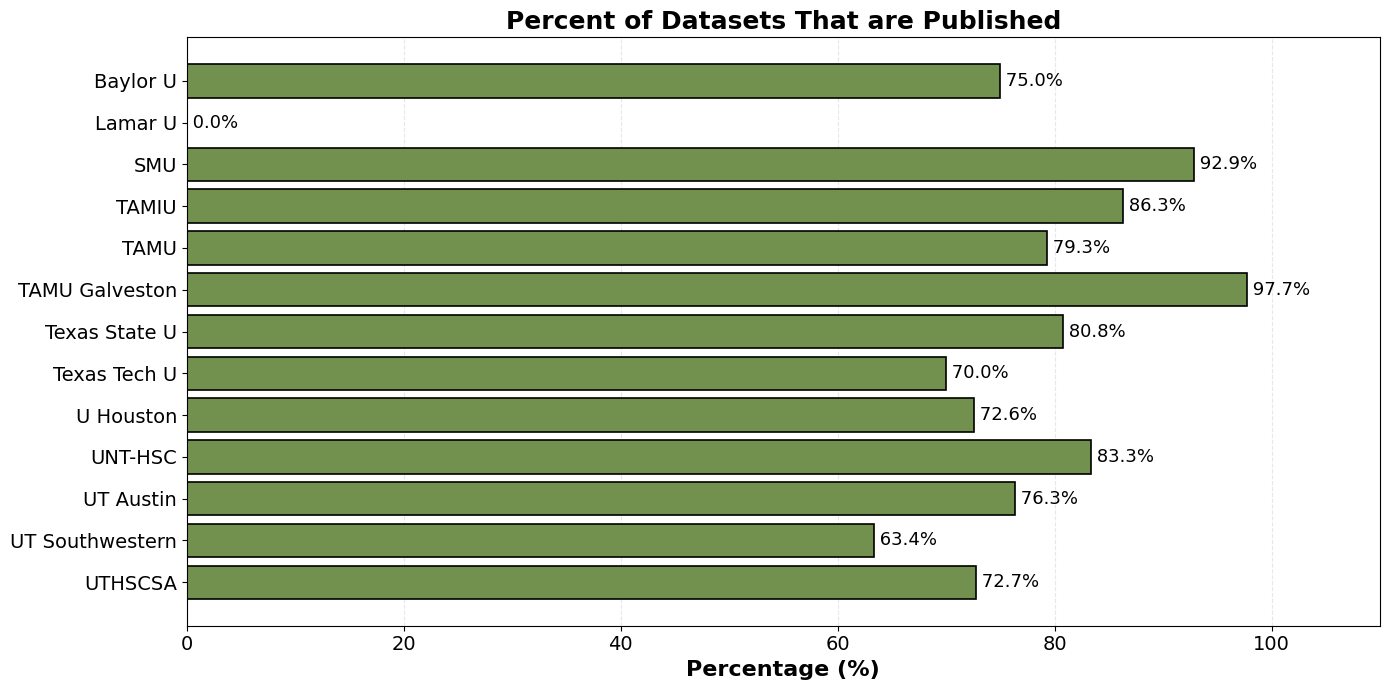

In [115]:
fig, ax = plt.subplots(figsize=(img_width, img_height))

publication_rates = []

for school in current_members:
    created = datasets_created_by_affiliation.get(school, 0)
    published = datasets_published_by_affiliation.get(school, 0)
    if created > 0:
        rate = (published / created) * 100
    else:
        rate = 0
    publication_rates.append((school, rate, created, published))

# Sort by school name in descending alphabetical order
publication_rates.sort(key=lambda x: x[0], reverse=True)

# Extract sorted data
sorted_schools = [f"{item[0]}" for item in publication_rates]
sorted_rates = [item[1] for item in publication_rates]
sorted_school_names = [item[0] for item in publication_rates]

y_pos = np.arange(len(sorted_schools))
colors = [school_colors.get(name, 'gray') for name in sorted_school_names]

ax.barh(y_pos, sorted_rates, color="#72914E", edgecolor='black', linewidth=1.2)

for i, rate in enumerate(sorted_rates):
    ax.text(rate, i, f' {rate:.1f}%', ha='left', va='center', fontsize=13)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_schools)
ax.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax.set_title('Percent of Datasets That are Published', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, 110)

plt.tight_layout()
plt.show()

## Slide 22: Published Datasets by Subject

C:\Users\bmg3525\AppData\Local\Temp\ipykernel_20828\2656479571.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab20')(np.linspace(1, 0, num_colors))


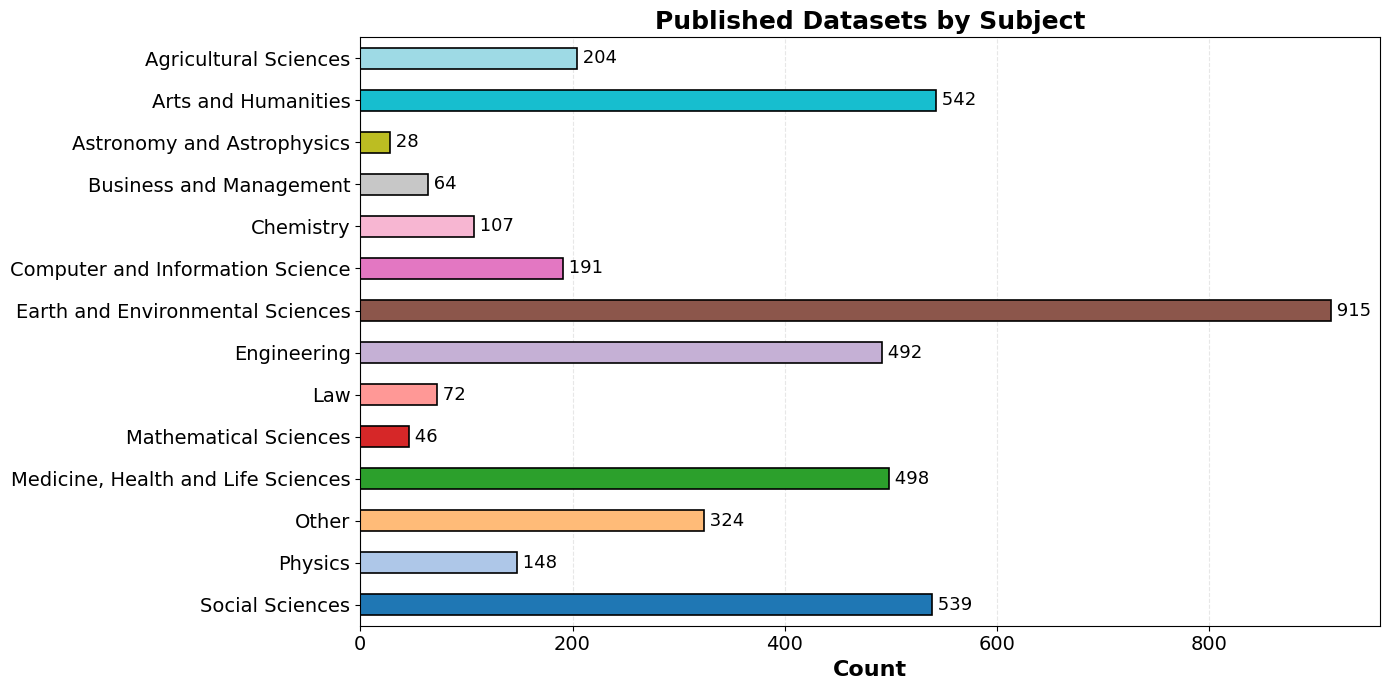

In [116]:
#| echo: false
#| warning: false

datasets_plot = datasets.copy()
datasets_plot['subjects'] = datasets_plot['subjects'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Explode to split multi-subject datasets
df_exploded = datasets_plot.explode('subjects')

# Clean whitespace
## This should not exist in theory
df_exploded['subjects'] = df_exploded['subjects'].str.strip()

# Create color map for all subject-related graphs
all_subjects = sorted(df_exploded['subjects'].dropna().unique())
num_colors = len(all_subjects)
colors = cm.get_cmap('tab20')(np.linspace(1, 0, num_colors))
subject_color_map = {subject: colors[i] for i, subject in enumerate(all_subjects)}
datasets_by_subject = df_exploded['subjects'].groupby(df_exploded['subjects']).count()
datasets_by_subject = datasets_by_subject.sort_index(ascending=False)
bar_colors = [subject_color_map[subject] for subject in datasets_by_subject.index]

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Add value labels
for i, (idx, value) in enumerate(datasets_by_subject.items()):
    ax.text(value, i, f' {int(value)}', va='center', fontsize=13)

# Use the consistent color mapping
datasets_by_subject.plot(kind='barh', ax=ax, color=bar_colors, edgecolor='black', linewidth=1.2)

ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Published Datasets by Subject', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Slide 23: Relative Proportion of Datasets by Subject and Institution

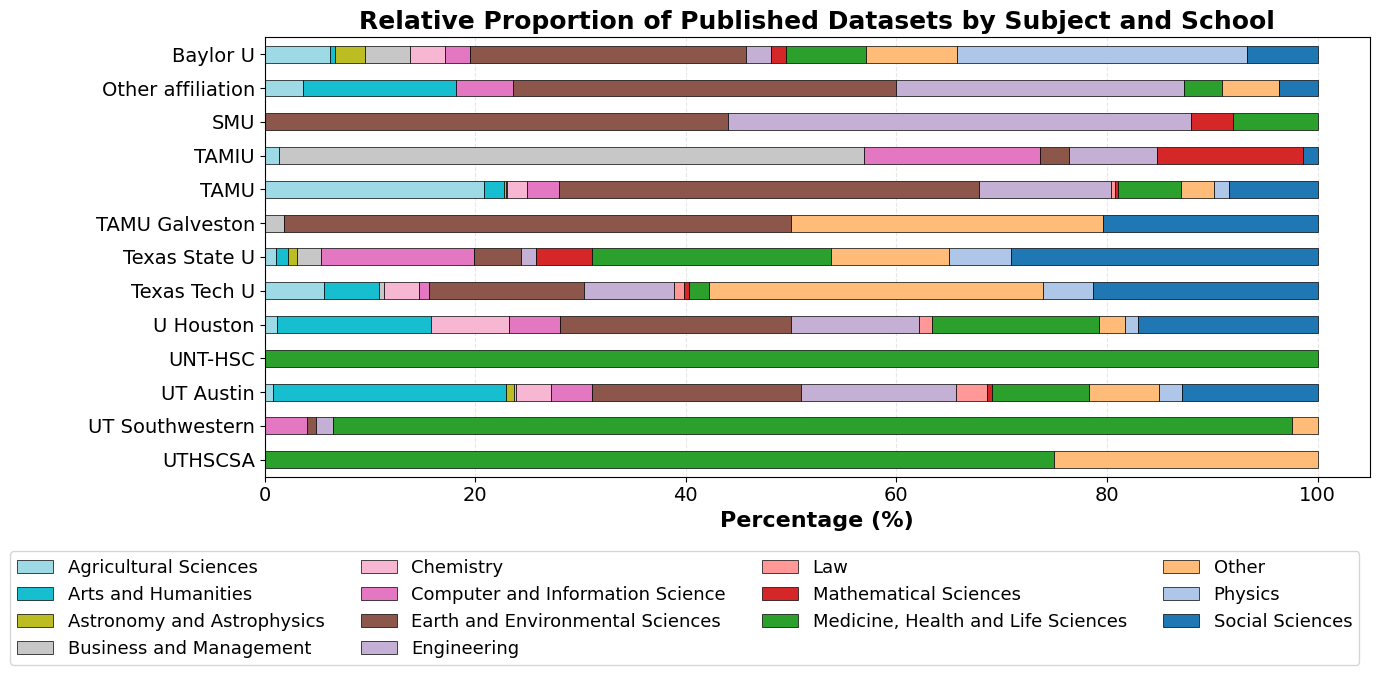

In [117]:
#| echo: false
#| warning: false

datasets_by_subject_school = df_exploded.groupby(['institution_standardized', 'subjects']).size().reset_index(name='count')

pivot_df = datasets_by_subject_school.pivot(index='institution_standardized', columns='subjects', values='count').fillna(0)
pivot_df = pivot_df.sort_index(ascending=False)

# Calculate percentages (relative counts)
pivot_pct = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(img_width, img_height))

# Map colors to the columns in pivot_pct
plot_colors = [subject_color_map[subject] for subject in pivot_pct.columns]

pivot_pct.plot(kind='barh', stacked=True, ax=ax, color=plot_colors, edgecolor='black', linewidth=0.5)

# Labels, etc.
ax.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_title('Relative Proportion of Published Datasets by Subject and School', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.legend(title='', bbox_to_anchor=(0.38, -0.15), loc='upper center', fontsize=legend_font, ncol=4)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Slide 24: Dataset Metrics by Metric Bin

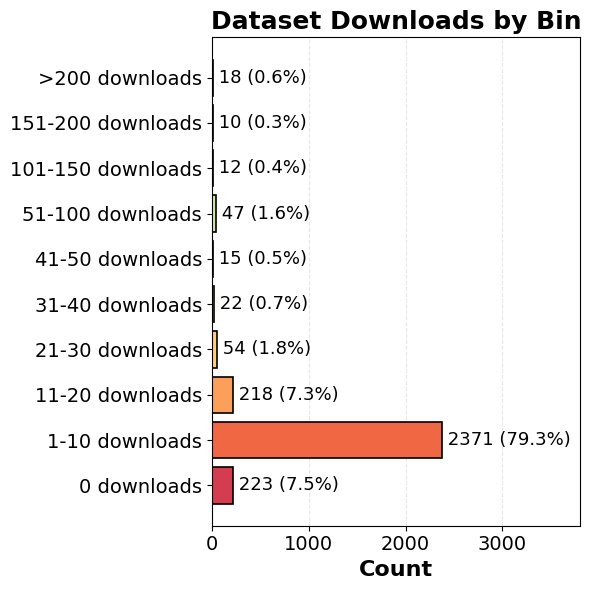

In [118]:
#| echo: false
#| warning: false
# Create the figure and axis
datasets_plot = datasets.copy()

# Create bins for last login
def bin_downloads(count):
    if pd.isna(count):
        return 'Unpublished'
    elif count == 0:
        return '0 downloads'
    elif count <= 10:
        return '1-10 downloads'
    elif count <= 20:
        return '11-20 downloads'
    elif count <= 30:
        return '21-30 downloads'
    elif count <= 40:
        return '31-40 downloads'
    elif count <= 50:
        return '41-50 downloads'
    elif count <= 100:
        return '51-100 downloads'
    elif count <= 150:
        return '101-150 downloads'
    elif count <= 200:
        return '151-200 downloads'
    else:
        return '>200 downloads'

datasets_plot['downloads_bin'] = datasets_plot['downloads_dc'].apply(bin_downloads)
downloads_count = datasets_plot['downloads_bin'].value_counts()

category_order = [
    # 'Unpublished',
    '0 downloads',
    '1-10 downloads',
    '11-20 downloads',
    '21-30 downloads',
    '31-40 downloads',
    '41-50 downloads',
    '51-100 downloads',
    '101-150 downloads',
    '151-200 downloads',
    '>200 downloads'
]

n_categories = len(category_order)

# Reorder the series
downloads_count = downloads_count.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(6, 6))

# Create horizontal bar plot
colors = cm.Spectral(np.linspace(0.1, 0.9, n_categories))
bars = ax.barh(range(len(downloads_count)), downloads_count.values, color=colors, edgecolor='black', linewidth=1.2)

# Customize the plot
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Dataset Downloads by Bin', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.set_xlim(0, 3000)

# Set y-axis labels
ax.set_yticks(range(len(downloads_count)))
ax.set_yticklabels(downloads_count.index)

# Add value labels at the end of bars
for idx, (bar, value) in enumerate(zip(bars, downloads_count.values)):
    width = bar.get_width()
    pct = (value / downloads_count.sum()) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(value)} ({pct:.1f}%)',
            ha='left', va='center', fontsize=13)

# Add grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, 3800)

# Adjust layout
plt.tight_layout()

# Display
plt.show()

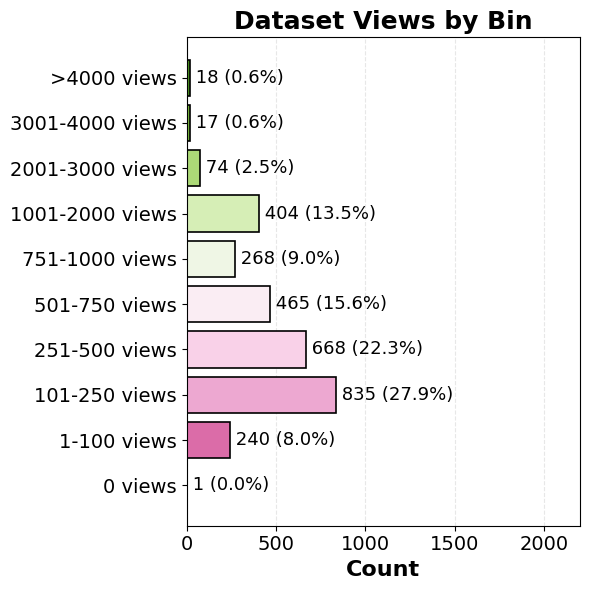

In [119]:
#| echo: false
#| warning: false

# Create bins for last login
def bin_views(count):
    if pd.isna(count):
        return 'Unpublished'
    elif count == 0:
        return '0 views'
    elif count <= 100:
        return '1-100 views'
    elif count <= 250:
        return '101-250 views'
    elif count <= 500:
        return '251-500 views'
    elif count <= 750:
        return '501-750 views'
    elif count <= 1000:
        return '751-1000 views'
    elif count <= 2000:
        return '1001-2000 views'
    elif count <= 3000:
        return '2001-3000 views'
    elif count <= 4000:
        return '3001-4000 views'
    else:
        return '>4000 views'

datasets_plot['views_bin'] = datasets_plot['views_dc'].apply(bin_views)

views_count = datasets_plot['views_bin'].value_counts()

category_order = [
    # 'Unpublished',
    '0 views',
    '1-100 views',
    '101-250 views',
    '251-500 views',
    '501-750 views',
    '751-1000 views',
    '1001-2000 views',
    '2001-3000 views',
    '3001-4000 views',
    '>4000 views'
]

# Reorder the series
views_count = views_count.reindex(category_order)

###########################################
###             PLOT                    ###
###########################################

fig, ax = plt.subplots(figsize=(6, 6))

colors = cm.PiYG(np.linspace(0.1, 0.9, n_categories))
bars = ax.barh(range(len(views_count)), views_count.values, color=colors, edgecolor='black', linewidth=1.2)

# Labels, etc.
ax.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax.set_xlabel('Count', fontsize=axis_font, fontweight='bold')
ax.set_title('Dataset Views by Bin', fontsize=title_font, fontweight='bold')
ax.tick_params(labelsize=tick_font)
ax.set_xlim(0, 3000)
ax.set_yticks(range(len(views_count)))
ax.set_yticklabels(views_count.index)

# Add value labels at the end of bars
for idx, (bar, value) in enumerate(zip(bars, views_count.values)):
    width = bar.get_width()
    pct = (value / views_count.sum()) * 100
    ax.text(width, bar.get_y() + bar.get_height()/2.,
            f' {int(value)} ({pct:.1f}%)',
            ha='left', va='center', fontsize=13)

# Add grid for readability
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.set_xlim(0, 2200)

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Alternative to Slide 24 (Downloads only)

This is a donut chart showing the same information as in the bar graph.

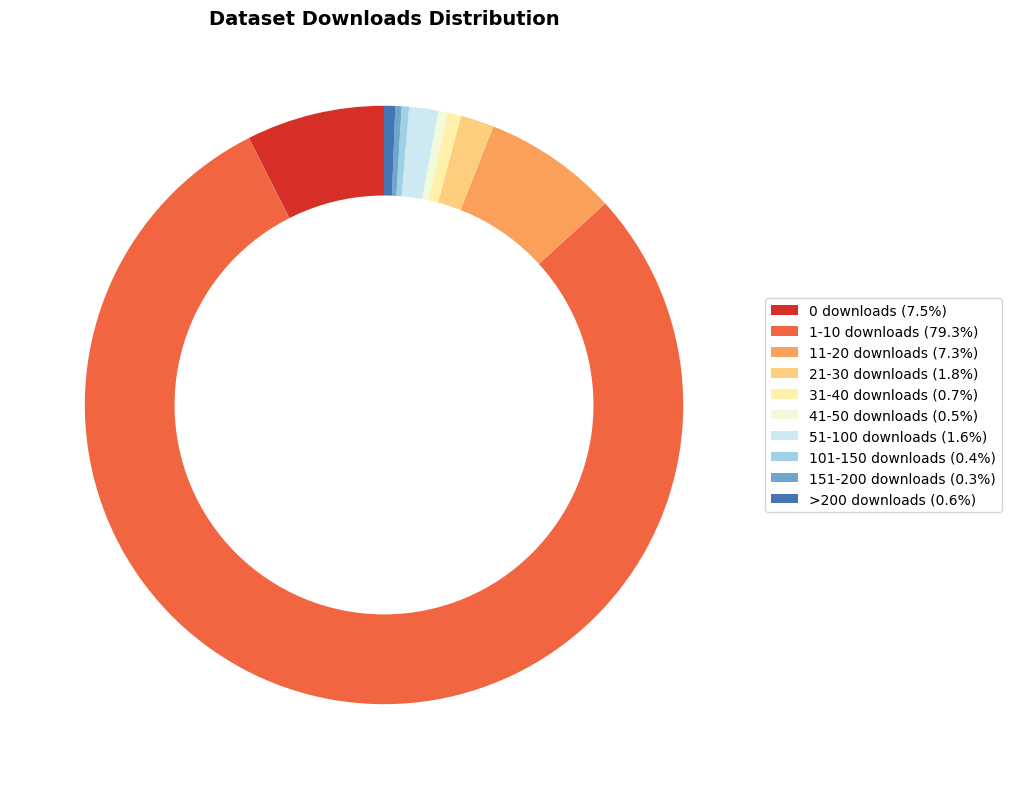

In [120]:
#| echo: false
#| warning: false

# Create a copy to avoid modifying the original
datasets_plot = datasets.copy()

# Create bins for last login
def bin_downloads(count):
    if pd.isna(count):
        return 'Unpublished'
    elif count == 0:
        return '0 downloads'
    elif count <= 10:
        return '1-10 downloads'
    elif count <= 20:
        return '11-20 downloads'
    elif count <= 30:
        return '21-30 downloads'
    elif count <= 40:
        return '31-40 downloads'
    elif count <= 50:
        return '41-50 downloads'
    elif count <= 100:
        return '51-100 downloads'
    elif count <= 150:
        return '101-150 downloads'
    elif count <= 200:
        return '151-200 downloads'
    else:
        return '>200 downloads'

datasets_plot['downloads_bin'] = datasets_plot['downloads_dc'].apply(bin_downloads)

# Count by bin
downloads_count = datasets_plot['downloads_bin'].value_counts()

category_order = [
    # 'Unpublished',
    '0 downloads',
    '1-10 downloads',
    '11-20 downloads',
    '21-30 downloads',
    '31-40 downloads',
    '41-50 downloads',
    '51-100 downloads',
    '101-150 downloads',
    '151-200 downloads',
    '>200 downloads'
]

# Reorder the series
downloads_count = downloads_count.reindex(category_order)

# Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each bin
n_categories = len(category_order)

# Generate gradient colors
colors = cm.RdYlBu(np.linspace(0.1, 0.9, n_categories))

# Create donut chart
# wedges, texts, autotexts = ax.pie(
#     downloads_count.values,
#     labels=downloads_count.index,
#     autopct='%1.1f%%',
#     startangle=90,
#     colors=colors,
#     textprops={'fontsize': 11},
#     pctdistance=0.85
# )

# for text in texts:
#     text.set_fontweight('bold')
#     text.set_fontsize(11)

# # Control percentage weight independently
# for autotext in autotexts:
#     autotext.set_fontweight('bold')
#     autotext.set_fontsize(10)
#     autotext.set_color('white')

wedges, texts = ax.pie(
    downloads_count.values,
    startangle=90,
    colors=colors
)

for text in autotexts:
    text.set_fontweight('bold')

# Create the donut hole
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
ax.add_artist(centre_circle)

# total_count = len(users_plot)
# ax.text(0, 0, f'{total_count} users (as of 5/1)', ha='center', va='center', 
#         fontsize=16, fontweight='bold', color="#5C5252")

# Customize the plot
ax.set_title('Dataset Downloads Distribution', fontsize=14, fontweight='bold', pad=5)

legend_labels = [f'{label} ({value/downloads_count.sum()*100:.1f}%)' 
                 for label, value in downloads_count.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)
# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Alternative to Slide 25 (downloads)

This is a faceted set of donut graphs showing what proportion of datasets published in each institution's collection have more than a certain threshold of downloads.

['Baylor U' 'SMU' 'TAMIU' 'TAMU' 'TAMU Galveston' 'Texas Tech U'
 'Texas State U' 'U Houston' 'UNT-HSC' 'Other affiliation' 'UT Austin'
 'UTHSCSA' 'UT Southwestern']


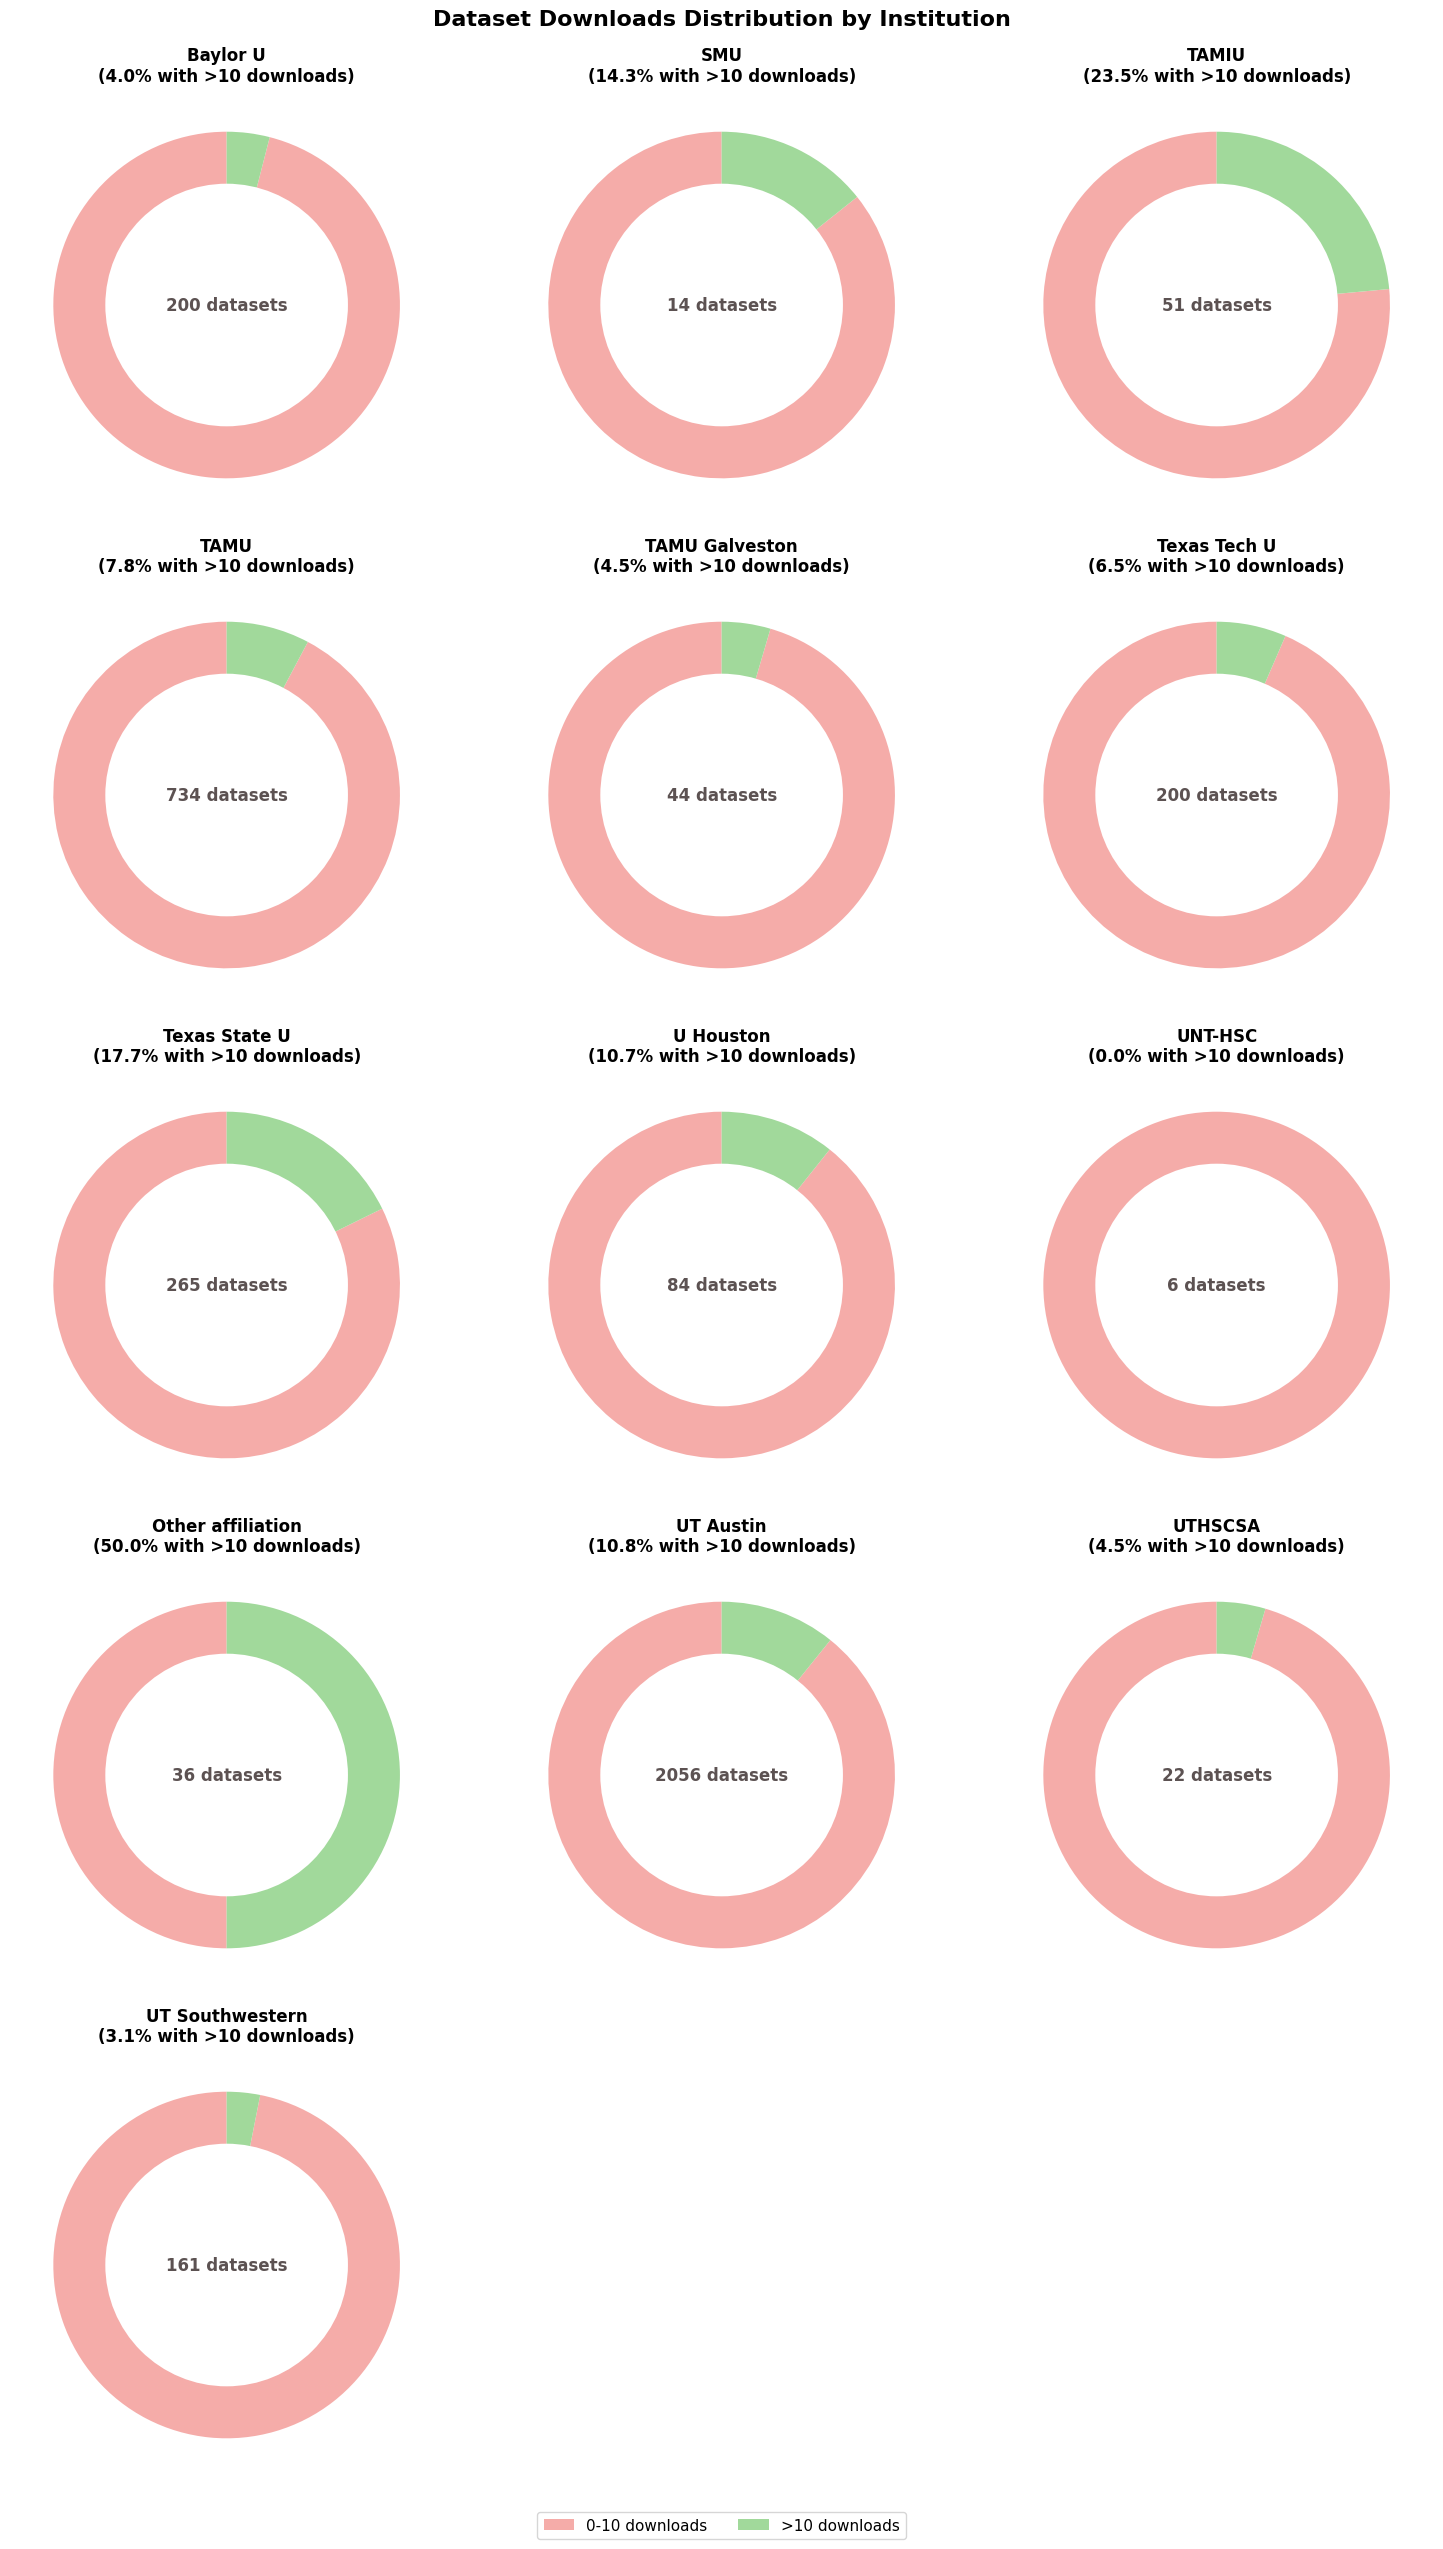

In [121]:
#| echo: false
#| warning: false

import matplotlib.cm as cm
import numpy as np

# Create a copy to avoid modifying the original
datasets_plot = datasets.copy()

# Simplified binning function
def bin_downloads(count):
    if pd.isna(count):
        return '0-10 downloads'
    elif count <= 10:
        return '0-10 downloads'
    else:
        return '>10 downloads'

datasets_plot['downloads_bin'] = datasets_plot['downloads_dc'].apply(bin_downloads)

# Get unique institutions
institutions = datasets_plot['institution_standardized'].unique()
print(institutions)
n_institutions = len(institutions)

# Create subplots (arrange in grid)
n_cols = 3
n_rows = (n_institutions + n_cols - 1) // n_cols  # Ceiling division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten to 1D for easier iteration

# Define colors for the two categories
colors = ["#f5aca9", '#a1d99b']  # Light red, light green

# Create a donut for each institution
for idx, institution in enumerate(institutions):
    ax = axes[idx]
    
    # Filter data for this institution
    inst_data = datasets_plot[datasets_plot['institution_standardized'] == institution]
    
    # Count by bin
    downloads_count = inst_data['downloads_bin'].value_counts()
    
    # Ensure both categories exist (fill missing with 0)
    category_order = ['0-10 downloads', '>10 downloads']
    downloads_count = downloads_count.reindex(category_order, fill_value=0)
    
    # Create donut chart
    wedges, texts = ax.pie(
        downloads_count.values,
        startangle=90,
        colors=colors
    )
    
    # Create the donut hole
    centre_circle = plt.Circle((0, 0), 0.70, fc='white')
    ax.add_artist(centre_circle)
    
    # Add title with institution name and total count
    total_count = len(inst_data)
    pct_over_10 = (downloads_count['>10 downloads'] / downloads_count.sum()) * 100

    ax.set_title(f'{institution}\n({pct_over_10:.1f}% with >10 downloads)', 
                 fontsize=12, fontweight='bold', pad=5)
    # ax.set_title(f'{institution}\n({pct_over_10:.1f}% >10 downloads)', 
    #              fontsize=12, fontweight='bold', pad=20)

    # Add dataset total count to middle
    ax.text(0, 0, f'{total_count} datasets', ha='center', va='center', 
        fontsize=12, fontweight='bold', color="#5C5252")
    

# Hide unused subplots
for idx in range(n_institutions, len(axes)):
    axes[idx].set_visible(False)

# Single legend for all
legend_labels = category_order
fig.legend(legend_labels, loc='lower center', ncol=2, fontsize=11, 
           bbox_to_anchor=(0.5, -0.02), frameon=True)

# Overall title
fig.suptitle('Dataset Downloads Distribution by Institution', 
             fontsize=16, fontweight='bold', y=0.995)

# Adjust layout
plt.tight_layout()

# Display
plt.show()

## Slide 25: Metrics Table

In [122]:
datasets_filtered = datasets_plot[~datasets_plot['institution_standardized'].isin(['No affiliation', 'Other affiliation'])]

# Calculate downloads stats by institution
stats_by_institution = datasets_filtered.groupby('institution_standardized')['downloads_dc'].agg([
    ('Median', 'median'),
    ('Mode', lambda x: x.mode()[0] if len(x.mode()) > 0 else 0),
    ('Max', 'max')
]).sort_values('Median', ascending=False)

# Convert to int, handling NaN values
stats_by_institution = stats_by_institution.fillna(0).astype(int)

# Reset index to make institution a column
stats_table = stats_by_institution.reset_index()
stats_table.columns = ['Institution', 'Median', 'Mode', 'Max']

# Sort by Institution name in descending alphabetical order
stats_table = stats_table.sort_values('Institution', ascending=True)

# Create styled table
styled = stats_table.style\
    .background_gradient(subset=['Median'], cmap='RdYlGn', vmin=stats_table['Median'].min(), vmax=stats_table['Median'].max())\
    .background_gradient(subset=['Mode'], cmap='Blues', vmin=stats_table['Mode'].min(), vmax=stats_table['Mode'].max())\
    .background_gradient(subset=['Max'], cmap='Oranges', vmin=stats_table['Max'].min(), vmax=stats_table['Max'].max())\
    .format({'Median': '{:.0f}', 'Mode': '{:.0f}', 'Max': '{:.0f}'})\
    .set_caption('Download Statistics by Institution')\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', "#35558D"), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('text-align', 'center'), ('padding', '10px'), ('font-size', '14pt'), ('font-weight', 'bold')]}
    ])

styled

,Institution,Median,Mode,Max
8,Baylor U,3,2,32
0,SMU,7,0,13
1,TAMIU,5,3,88
5,TAMU,4,3,285
2,TAMU Galveston,5,3,19
3,Texas State U,5,1,480
9,Texas Tech U,3,3,127
4,U Houston,5,3,30
10,UNT-HSC,1,0,6
6,UT Austin,4,2,4268


In [123]:
# Calculate views stats by institution
stats_by_institution = datasets_filtered.groupby('institution_standardized')['views_dc'].agg([
    ('Median', 'median'),
    # ('Mode', lambda x: x.mode()[0] if len(x.mode()) > 0 else 0),
    ('Max', 'max')
]).sort_values('Median', ascending=False)

# Convert to int, handling NaN values
stats_by_institution = stats_by_institution.fillna(0).astype(int)

# Reset index to make institution a column
stats_table = stats_by_institution.reset_index()
stats_table.columns = ['Institution', 'Median', 'Max']

# Sort by Institution name in descending alphabetical order
stats_table = stats_table.sort_values('Institution', ascending=True)

# Create styled table
styled = stats_table.style\
    .background_gradient(subset=['Median'], cmap='RdYlGn', vmin=stats_table['Median'].min(), vmax=stats_table['Median'].max())\
    .background_gradient(subset=['Max'], cmap='Oranges', vmin=stats_table['Max'].min(), vmax=stats_table['Max'].max())\
    .format({'Median': '{:.0f}', 'Max': '{:.0f}'})\
    .set_caption('View Statistics by Institution')\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#35558D'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
        {'selector': 'caption', 'props': [('text-align', 'center'), ('padding', '10px'), ('font-size', '14pt'), ('font-weight', 'bold')]}
    ])

styled

,Institution,Median,Max
0,Baylor U,595,2664
2,SMU,465,1522
1,TAMIU,548,2518
9,TAMU,277,3481
4,TAMU Galveston,427,5326
8,Texas State U,320,9821
11,Texas Tech U,200,9018
10,U Houston,253,3615
5,UNT-HSC,413,889
3,UT Austin,446,9452


## Slide 28: File Count by Total Files

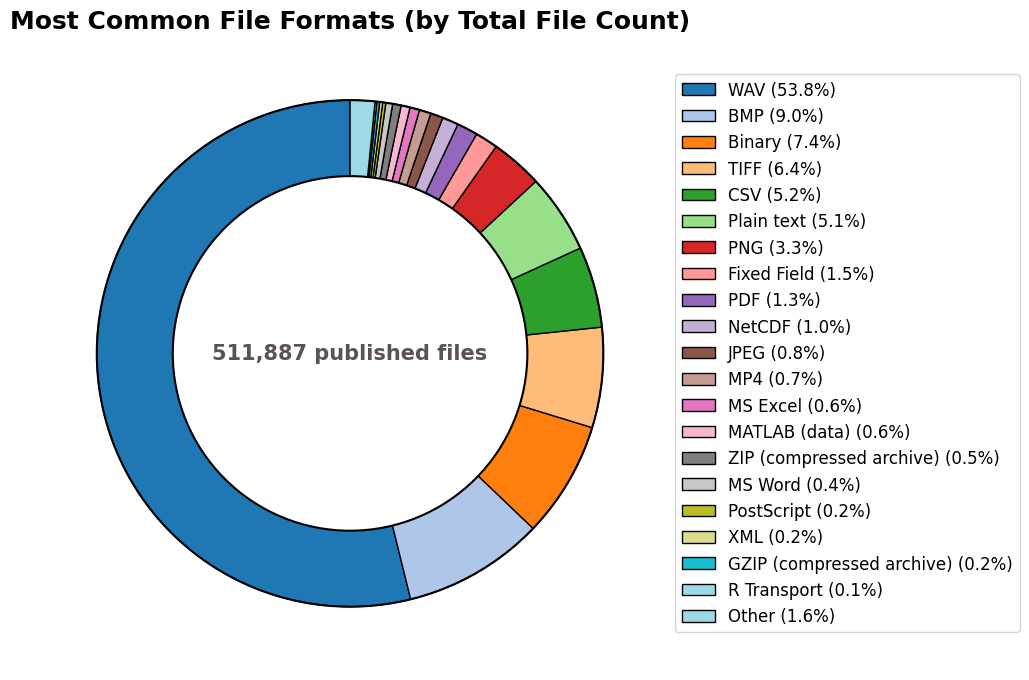

In [124]:
#| echo: false
#| warning: false

files_plot = files.copy()

files_by_type = files_plot['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_type = files_by_type.sort_values(ascending=False)

cut = 20
top = files_by_type.head(cut)
other_count = files_by_type.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_type = top

fig, ax = plt.subplots(figsize=(img_width, img_height))

colors = plt.cm.tab20(range(len(files_by_type)))

wedges, texts, autotexts = ax.pie(
    files_by_type.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(border)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Remove the label text around the donut
for text in texts:
    text.set_visible(False)

# Draw circle in the center to create donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
ax.add_artist(centre_circle)

# Add count to middle
total_count = len(files_plot)
ax.text(0, 0, f'{total_count:,} published files', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Create legend with labels and percentages
legend_labels = [f'{label} ({value/files_by_type.sum()*100:.1f}%)' 
                 for label, value in files_by_type.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

ax.set_title('Most Common File Formats (by Total File Count)', fontsize=title_font, fontweight='bold')
plt.tight_layout()
plt.show()

## Slide 29: Comparison of File Count Methods

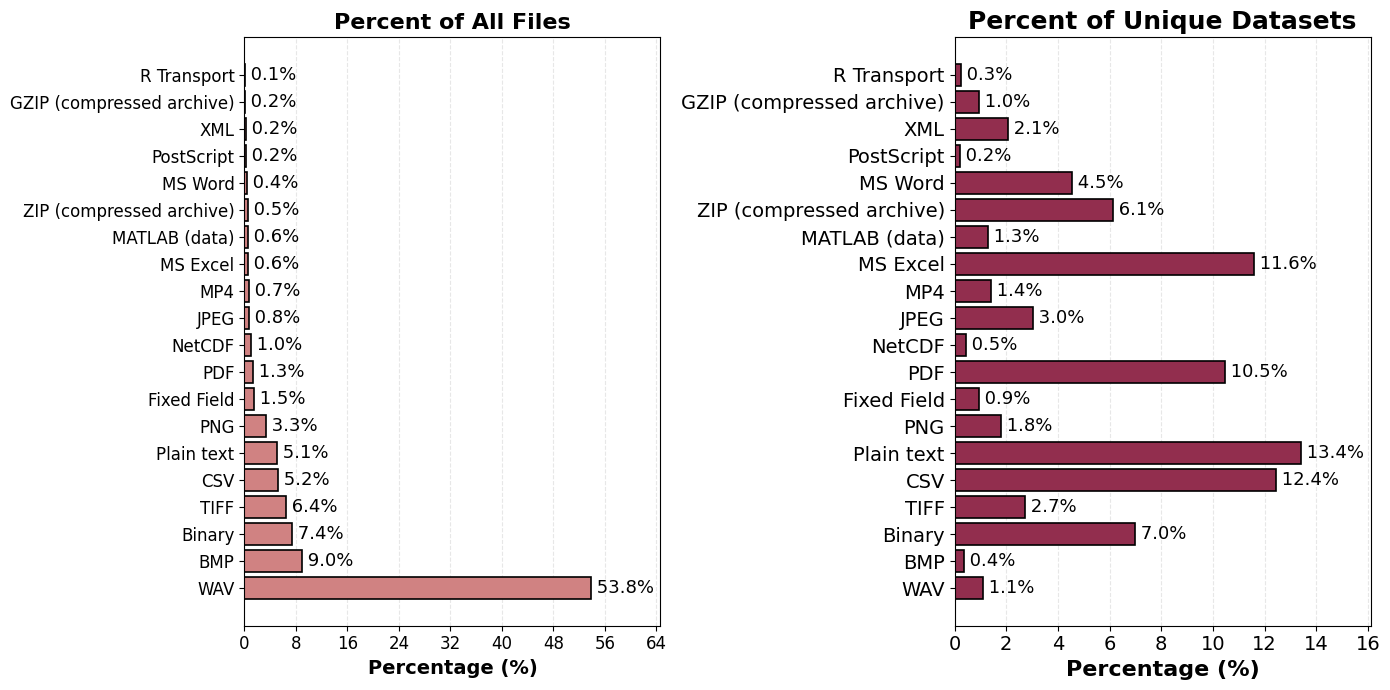

In [125]:
# Get top N (cut) formats by total file count
files_by_type = files_plot['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_type = files_by_type.sort_values(ascending=False)
cut = 20
top = files_by_type.head(cut)
other_count = files_by_type.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_type = top

total = files_by_type.sum()
files_by_type_pct = (files_by_type / total) * 100
top_formats_all = files_by_type_pct.head(cut)

files_plot = files.copy()

files_plots_dedup = files_plot.drop_duplicates(subset=['doi', 'friendly_format_manual'], keep='first')
files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)
total = files_by_dataset.sum()
files_by_dataset_pct = (files_by_dataset / total) * 100

# Filter to only formats that are in top 15 by all files
unique_per_dataset_pct = files_by_dataset_pct[files_by_dataset_pct.index.isin(top_formats_all.index)]

# Sort both by top_formats_all (descending)
top_formats_all = top_formats_all.sort_values(ascending=False)
unique_per_dataset_pct = unique_per_dataset_pct[top_formats_all.index]

# Create figure with 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(img_width, img_height))

y_pos = np.arange(len(top_formats_all))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_formats_all)))

# Left plot: All Files percentage
ax1.barh(y_pos, top_formats_all.values, color="#d08282", edgecolor='black', linewidth=1.2)

for i, pct in enumerate(top_formats_all.values):
    ax1.text(pct, i, f' {pct:.1f}%', ha='left', va='center', fontsize=13)

ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_formats_all.index)
ax1.set_xlabel('Percentage (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('', fontsize=14, fontweight='bold')
ax1.set_title('Percent of All Files', fontsize=16, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add padding for labels
x_max = top_formats_all.max()
ax1.set_xlim(0, x_max * 1.2)

# Right plot: Unique per Dataset percentage
ax2.barh(y_pos, unique_per_dataset_pct.values, color="#922e4e", edgecolor='black', linewidth=1.2)

for i, pct in enumerate(unique_per_dataset_pct.values):
    ax2.text(pct, i, f' {pct:.1f}%', ha='left', va='center', fontsize=13)

ax2.set_yticks(y_pos)
ax2.set_yticklabels(unique_per_dataset_pct.index)
ax2.set_xlabel('Percentage (%)', fontsize=axis_font, fontweight='bold')
ax2.set_ylabel('', fontsize=axis_font, fontweight='bold')
ax2.set_title('Percent of Unique Datasets', fontsize=title_font, fontweight='bold')
ax2.tick_params(labelsize=tick_font)
ax2.grid(axis='x', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add padding for labels
x_max = unique_per_dataset_pct.max()
ax2.set_xlim(0, x_max * 1.2)

# Force percents to integers
ax1.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax2.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

## Alternative to Slide 29

This is nearly identical (minus color palette) to the utilized version, just with the right graph flipped across the y-axis.

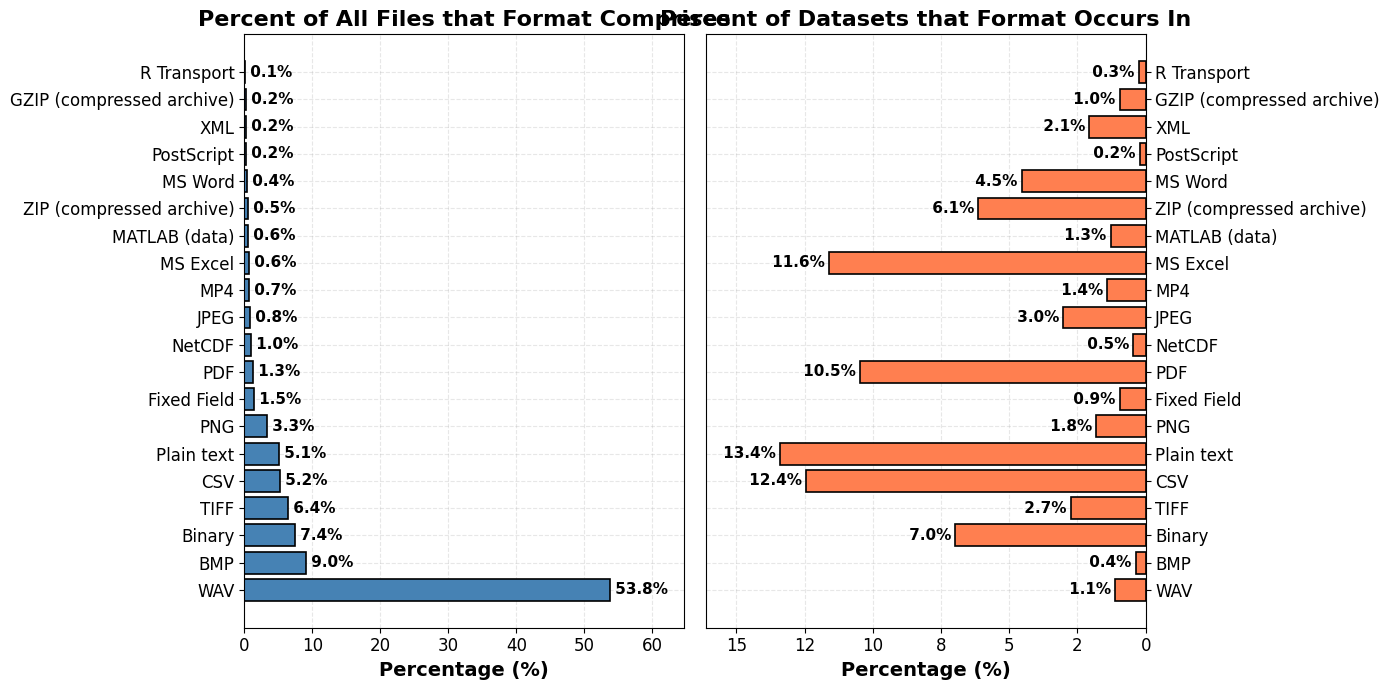

In [126]:
# Get top N formats by total file count
top_formats_all = files_by_type_pct.head(cut)

files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)
total = files_by_dataset.sum()
files_by_dataset_pct = (files_by_dataset / total) * 100

# Filter to only formats that are in top 15 by all files
unique_per_dataset_pct = files_by_dataset_pct[files_by_dataset_pct.index.isin(top_formats_all.index)]

# Sort both by top_formats_all (descending)
top_formats_all = top_formats_all.sort_values(ascending=False)
unique_per_dataset_pct = unique_per_dataset_pct[top_formats_all.index]

# Create figure with 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

y_pos = np.arange(len(top_formats_all))
colors = plt.cm.tab20(np.linspace(0, 1, len(top_formats_all)))

# Left plot: All Files percentage
ax1.barh(y_pos, top_formats_all.values, color='steelblue', edgecolor='black', linewidth=1.2)

for i, pct in enumerate(top_formats_all.values):
    ax1.text(pct, i, f' {pct:.1f}%', ha='left', va='center', fontsize=11, fontweight='bold')

ax1.set_yticks(y_pos)
ax1.set_yticklabels(top_formats_all.index)
ax1.set_xlabel('Percentage (%)', fontsize=14, fontweight='bold')
ax1.set_ylabel('', fontsize=14, fontweight='bold')
ax1.set_title('Percent of All Files that Format Comprises', fontsize=16, fontweight='bold')
ax1.tick_params(labelsize=12)
ax1.grid(axis='both', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# Add padding for labels
x_max = top_formats_all.max()
ax1.set_xlim(0, x_max * 1.2)

# Right plot: Unique per Dataset percentage (flipped)
ax2.barh(y_pos, -unique_per_dataset_pct.values, color='coral', edgecolor='black', linewidth=1.2)

for i, pct in enumerate(unique_per_dataset_pct.values):
    ax2.text(-pct - 0.15, i, f' {pct:.1f}%', ha='right', va='center', fontsize=11, fontweight='bold')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(unique_per_dataset_pct.index)
ax2.yaxis.tick_right()  # Move y-axis labels to the right
ax2.yaxis.set_label_position('right')  # Move y-axis label to the right
ax2.set_xlabel('Percentage (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('', fontsize=14, fontweight='bold')
ax2.set_title('Percent of Datasets that Format Occurs In', fontsize=16, fontweight='bold')
ax2.tick_params(labelsize=12)
ax2.grid(axis='both', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# Add padding for labels (negative values)
x_max = unique_per_dataset_pct.max()
ax2.set_xlim(-x_max * 1.2, 0)

# Format x-axis to show absolute values
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{abs(x):.0f}'))

plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

## Alternative to Slide 29

This is a line-dot graph that compares the relative ranks of file formats by total file count and by number of datasets with at least one file of a given format.

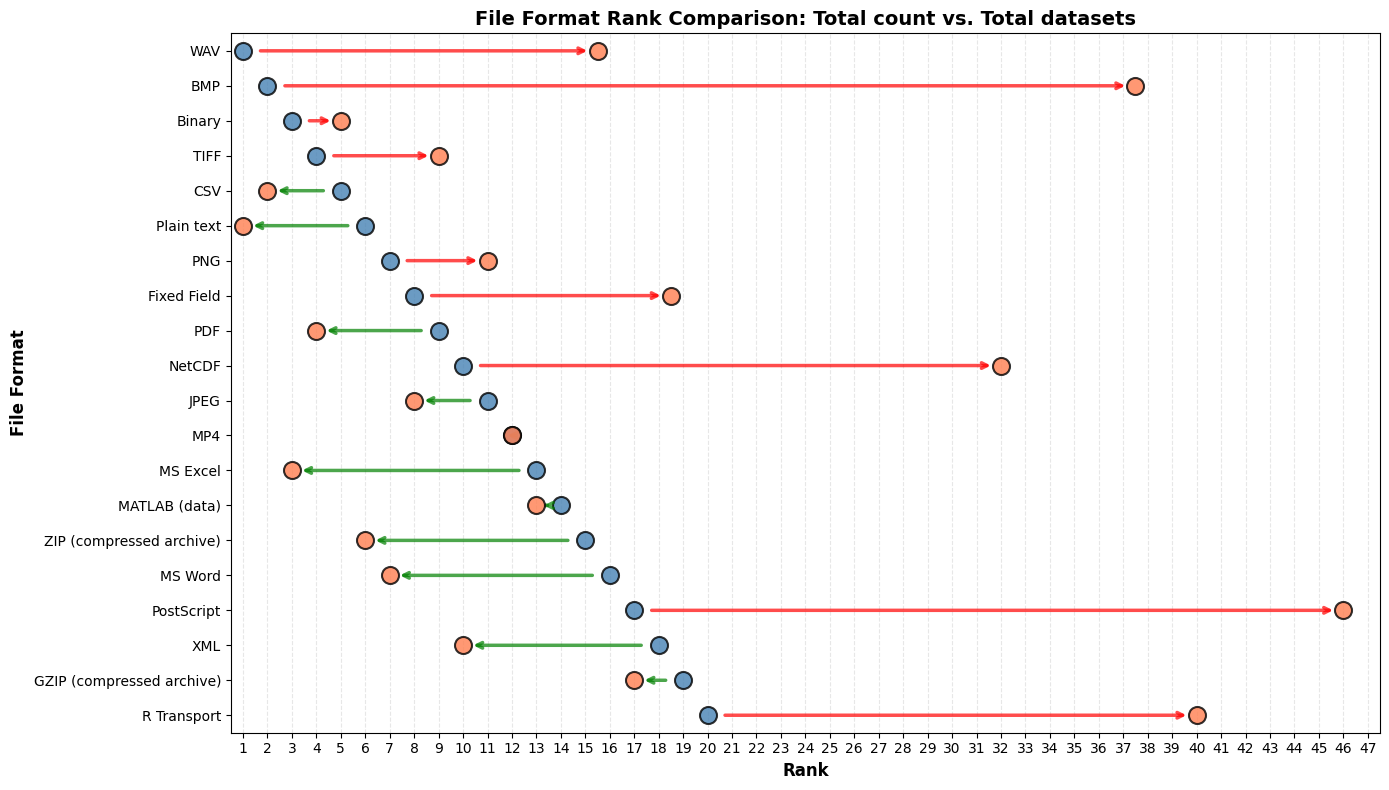

In [127]:
#| echo: false
#| warning: false

# Get top N formats by total file count
top_formats_all = files_by_type_pct.head(cut)

files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)
total = files_by_dataset.sum()
files_by_dataset_pct = (files_by_dataset / total) * 100

unique_per_dataset_ranked_all = files_by_dataset_pct.rank(ascending=False)
# Filter to only formats that are in top 15 by all files, but keep their original ranks
unique_per_dataset_ranked = unique_per_dataset_ranked_all[unique_per_dataset_ranked_all.index.isin(top_formats_all.index)]
# print(unique_per_dataset_ranked)

# Create ranks
all_files_ranked = top_formats_all.rank(ascending=False)

max_rank_all = all_files_ranked.max()
max_rank_unique = unique_per_dataset_ranked.max()
max_rank = max(max_rank_all, max_rank_unique)

# print(f"Max rank (all files): {max_rank_all}")
# print(f"Max rank (unique, before filtering): {max_rank_unique}")
# print(f"Max rank overall: {max_rank}")

fig, ax = plt.subplots(figsize=(14, 8))

circle_radius = 0.15

# Plot circles and arrows for each format
circle_radius = 0.3

# Plot circles and arrows for each format
for i, format_type in enumerate(all_files_ranked.index):
    rank_all = all_files_ranked[format_type]
    rank_unique = unique_per_dataset_ranked[format_type]
    
    # y position is the index (0 to top_n-1)
    y_pos = i
    
    # Plot circle for all files rank
    ax.scatter(rank_all, y_pos, s=150, alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5, zorder=3, label='All Files' if i == 0 else '')
    
    # Determine arrow direction and color based on rank change
    if rank_unique > rank_all:
        # Moving right (less dominant per dataset) - red arrow
        arrow_color = 'red'
        arrow_start_x = rank_all + (2*circle_radius)
        arrow_end_x = rank_unique - circle_radius
    elif rank_unique < rank_all:
        # Moving left (more dominant per dataset) - green arrow
        arrow_color = 'green'
        arrow_start_x = rank_all - (2*circle_radius)
        arrow_end_x = rank_unique + circle_radius
    else:
        # No change - gray arrow
        arrow_color = 'gray'
        arrow_start_x = rank_all + circle_radius
        arrow_end_x = rank_unique - circle_radius
    
    # Plot arrow
    ax.annotate('', xy=(arrow_end_x, y_pos), xytext=(arrow_start_x, y_pos),
                arrowprops=dict(arrowstyle='->', lw=2.5, color=arrow_color, alpha=0.7))
    
    # Plot circle for unique per dataset rank
    ax.scatter(rank_unique, y_pos, s=150, alpha=0.8, color='coral', edgecolor='black', linewidth=1.5, zorder=3, label='Unique per Dataset' if i == 0 else '')

# Set up axes with proper limits
ax.set_xlim(0.5, max_rank + 1.5)
ax.set_ylim(-0.5, cut - 0.5)
ax.set_xlabel('Rank', fontsize=12, fontweight='bold')
ax.set_ylabel('File Format', fontsize=12, fontweight='bold')
ax.set_title('File Format Rank Comparison: Total count vs. Total datasets', 
             fontsize=14, fontweight='bold')

# Set y-axis to show format names
ax.set_yticks(range(cut))
ax.set_yticklabels(all_files_ranked.index)

# Set x-axis ticks to show all ranks
ax.set_xticks(range(1, int(max_rank) + 2))

ax.grid(alpha=0.3, linestyle='--', axis='x')
ax.invert_yaxis()  # So first format is at the top
plt.tight_layout()
plt.show()

## Alternative to Slide 29

As with above, just reordered.

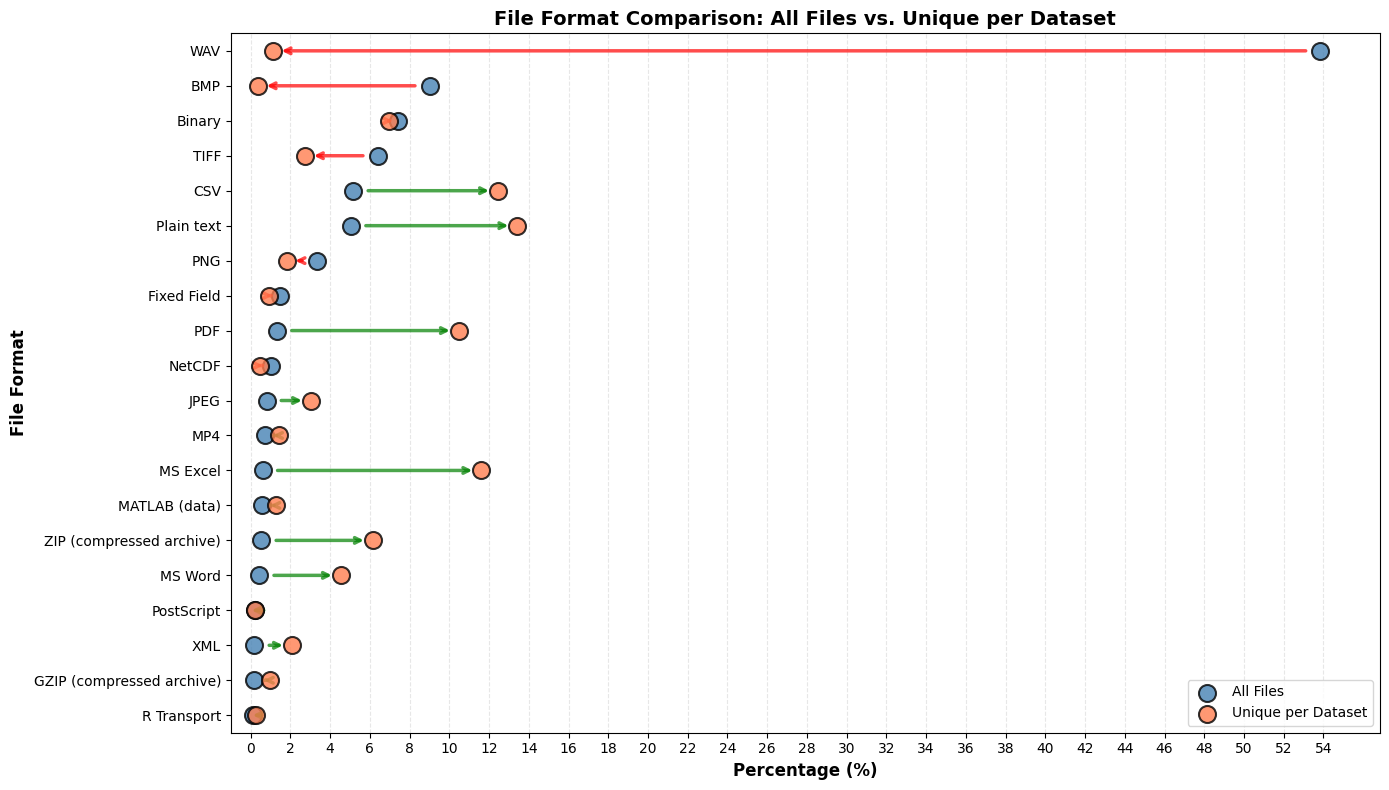

In [128]:
# Get top N formats by total file count
top_formats_all = files_by_type_pct.head(cut)

files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)
total = files_by_dataset.sum()
files_by_dataset_pct = (files_by_dataset / total) * 100

# Filter to only formats that are in top 15 by all files
unique_per_dataset_pct = files_by_dataset_pct[files_by_dataset_pct.index.isin(top_formats_all.index)]

fig, ax = plt.subplots(figsize=(14, 8))

circle_radius = 0.3

# Plot circles and arrows for each format
for i, format_type in enumerate(top_formats_all.index):
    pct_all = top_formats_all[format_type]
    pct_unique = unique_per_dataset_pct[format_type]
    
    # y position is the index (0 to top_n-1)
    y_pos = i
    
    # Plot circle for all files percentage
    ax.scatter(pct_all, y_pos, s=150, alpha=0.8, color='steelblue', edgecolor='black', linewidth=1.5, zorder=3, label='All Files' if i == 0 else '')
    
    # Determine arrow direction and color based on percentage change
    if pct_unique > pct_all:
        # Moving right (higher percentage per dataset)
        arrow_color = 'green'
        arrow_start_x = pct_all + (2*circle_radius)
        arrow_end_x = pct_unique - circle_radius
    elif pct_unique < pct_all:
        # Moving left (lower percentage per dataset)
        arrow_color = 'red'
        arrow_start_x = pct_all - (2*circle_radius)
        arrow_end_x = pct_unique + circle_radius
    else:
        # No change
        arrow_color = 'gray'
        arrow_start_x = pct_all + circle_radius
        arrow_end_x = pct_unique - circle_radius
    
    # Plot arrow
    ax.annotate('', xy=(arrow_end_x, y_pos), xytext=(arrow_start_x, y_pos),
                arrowprops=dict(arrowstyle='->', lw=2.5, color=arrow_color, alpha=0.7))
    
    # Plot circle for unique per dataset percentage
    ax.scatter(pct_unique, y_pos, s=150, alpha=0.8, color='coral', edgecolor='black', linewidth=1.5, zorder=3, label='Unique per Dataset' if i == 0 else '')
    
    # # Add percentage labels
    # ax.text(pct_all - 0.5, y_pos + 0.15, f'{pct_all:.1f}%', fontsize=9, ha='right', va='bottom')
    # ax.text(pct_unique + 0.5, y_pos + 0.15, f'{pct_unique:.1f}%', fontsize=9, ha='left', va='bottom')

# Set up axes with proper limits
max_pct = max(top_formats_all.max(), unique_per_dataset_pct.max())
ax.set_xlim(-1, max_pct + 3)
ax.set_ylim(-0.5, cut - 0.5)
ax.set_xlabel('Percentage (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('File Format', fontsize=12, fontweight='bold')
ax.set_title('File Format Comparison: All Files vs. Unique per Dataset', 
             fontsize=14, fontweight='bold')

# Set y-axis to show format names
ax.set_yticks(range(cut))
ax.set_yticklabels(top_formats_all.index)

# Set x-axis ticks
ax.set_xticks(range(0, int(max_pct) + 2, 2))

ax.grid(alpha=0.3, linestyle='--', axis='x')
ax.set_axisbelow(True)
ax.invert_yaxis()  # So first format is at the top
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

## Slide 30: File Formats by Unique Dataset Count

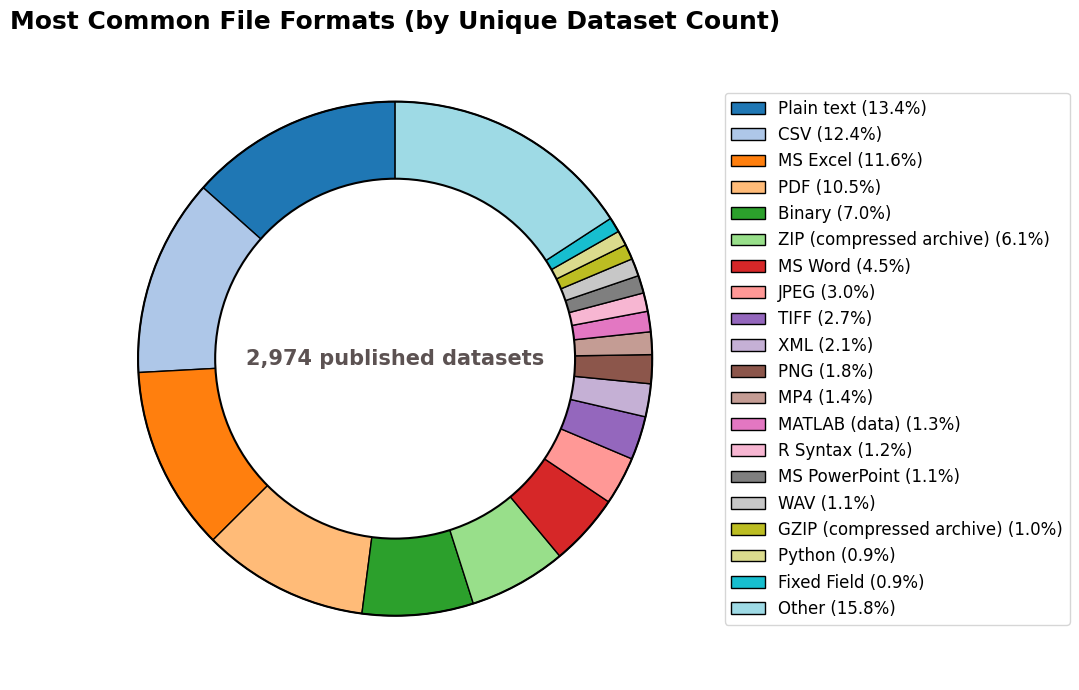

In [129]:
#| echo: false
#| warning: false
from matplotlib.patches import Circle
files_plot = files.copy()

files_plots_dedup = files_plot.drop_duplicates(subset=['doi', 'friendly_format_manual'], keep='first')

files_by_dataset = files_plots_dedup['friendly_format_manual'].groupby(files_plot['friendly_format_manual']).count()
files_by_dataset = files_by_dataset.sort_values(ascending=False)

cut = 19
top = files_by_dataset.head(cut)
other_count = files_by_dataset.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_dataset = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_dataset = top

fig, ax = plt.subplots(figsize=(img_width, img_height))

colors = plt.cm.tab20(range(len(files_by_dataset)))

wedges, texts, autotexts = ax.pie(
    files_by_dataset.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(border)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Remove the label text around the donut
for text in texts:
    text.set_visible(False)

# Draw circle in the center to create donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
ax.add_artist(centre_circle)

# Add count to middle
total_count = len(datasets_published_df)
ax.text(0, 0, f'{total_count:,} published datasets', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Create legend with labels and percentages
legend_labels = [f'{label} ({value/files_by_dataset.sum()*100:.1f}%)' 
                 for label, value in files_by_dataset.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

ax.set_title('Most Common File Formats (by Unique Dataset Count)', fontsize=title_font, fontweight='bold')
plt.tight_layout()
plt.show()

## Slide 31: File Formats by Collective Storage

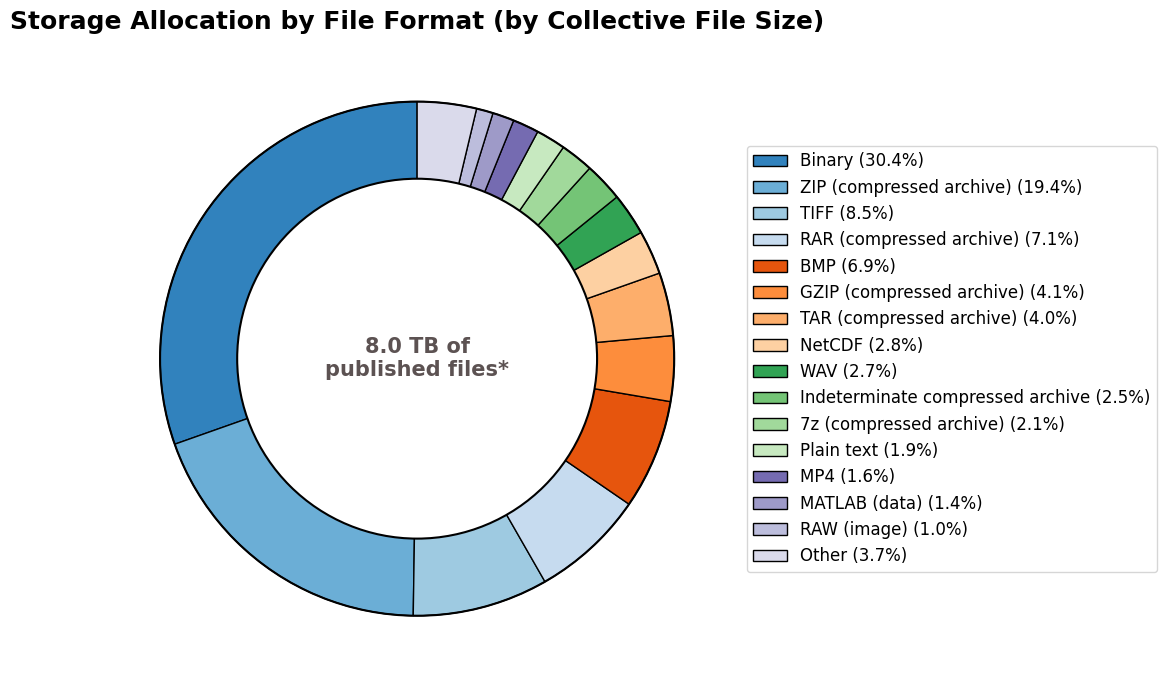

In [130]:
files_plot = files.copy()

# Sum file_size instead of counting
files_by_type = files_plot.groupby('friendly_format_manual')['file_size'].sum()
files_by_type = files_by_type.sort_values(ascending=False)

cut = 15
top = files_by_type.head(cut)
other_count = files_by_type.iloc[cut:].sum()

# Create new series with 'Other' category
if other_count > 0:
    files_by_type = pd.concat([top, pd.Series({'Other': other_count})])
else:
    files_by_type = top

fig, ax = plt.subplots(figsize=(img_width, img_height))

colors = plt.cm.tab20c(range(len(files_by_type)))

wedges, texts, autotexts = ax.pie(
    files_by_type.values,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    textprops={'fontsize': 10, 'weight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 1}
)

border = Circle((0, 0), 1, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(border)

# Make percentage text white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(9)

# Remove the label text around the donut
for text in texts:
    text.set_visible(False)

# Draw circle in the center to create donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white', color='black', linewidth=1.5)
ax.add_artist(centre_circle)

# Add total size to middle (convert bytes to GB)
total_size_tb = files_by_type.sum() / (1024**4)
ax.text(0, 0, f'{total_size_tb:,.1f} TB of\npublished files*', ha='center', va='center', 
        fontsize=15, fontweight='bold', color="#5C5252")

# Create legend with labels and percentages (also show size in GB)
# legend_labels = [f'{label} ({value/(1024**3):,.1f} GB, {value/files_by_type.sum()*100:.1f}%)' 
#                  for label, value in files_by_type.items()]
legend_labels = [f'{label} ({value/files_by_type.sum()*100:.1f}%)' 
                 for label, value in files_by_type.items()]
ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12)

ax.set_title('Storage Allocation by File Format (by Collective File Size)', fontsize=title_font, fontweight='bold')
plt.tight_layout()
plt.show()